# Sistema de recomendación y propensión de recompra — Instacart

Notebook reorganizado para el desarrollo de un recomendador cliente–producto utilizando historial de compras, similitud entre usuarios, Market Basket Analysis y LightGBM.

La construcción se realiza evitando utilizar el último pedido de cada usuario en las features: ese pedido se reserva como objetivo (`test`).


## Índice

1. Preparación del entorno  
2. Carga y construcción del dataset  
3. Exploratory Data Analysis (EDA) y enriquecimiento  
4. Split temporal Train / Validation / Test y usuarios elegibles  
5. Pipeline reutilizable de features por snapshot  
6. Construcción de Train y Validation  
7. Targets temporales  
8. Matrices de modelado  
9. Optimización temporal de LightGBM  
10. Modelo seleccionado y evaluación sobre Validation  
11. Auditorías y análisis complementarios  
12. Test final y métricas de ranking


# 1. Preparación del entorno

Dependencias e imports utilizados a lo largo del notebook. Las instalaciones son opcionales si el entorno ya dispone de los paquetes.


In [1]:
# Ejecutar solo si el entorno no tiene instaladas las dependencias.
# %pip install -q numpy pandas matplotlib seaborn scipy scikit-learn lightgbm duckdb tqdm wordcloud optuna shap


In [2]:
from pathlib import Path
from collections import Counter
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import duckdb
from tqdm.auto import tqdm

from scipy.sparse import csr_matrix
from sklearn.preprocessing import normalize
from sklearn.neighbors import NearestNeighbors
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    average_precision_score,
    precision_recall_curve,
    confusion_matrix,
    classification_report,
    log_loss,
)

import lightgbm as lgb
from lightgbm import LGBMClassifier
import optuna



In [3]:
# pip install plotly

In [4]:
import plotly

# 2. Carga y construcción del dataset

Se cargan las tablas de Instacart y se construye el detalle transaccional `data` mediante DuckDB.


## 2.0 Fuente de datos: Instacart

Instacart es una plataforma digital de compra y entrega de comestibles. El dataset contiene pedidos, productos, usuarios y secuencia temporal relativa entre órdenes.


In [5]:
DB_PATH = "instacart.duckdb"
from pathlib import Path
DATA_DIR = Path("/Users/Usuario/Downloads/Instacart")


files = {
    "orders": "orders.csv",
    "order_products__prior": "order_products__prior.csv",
    "order_products__train": "order_products__train.csv",
    "products": "products.csv",
    "departments": "departments.csv",
    "aisles": "aisles.csv",
}

with duckdb.connect(DB_PATH) as con:
    for table, fname in files.items():
        path = DATA_DIR / fname
        print(f"Creando tabla {table} desde {path}...")

        con.execute(f"""
            CREATE TABLE IF NOT EXISTS {table} AS
            SELECT * FROM read_csv_auto('{path.as_posix()}')
        """)

print("✔ Base creada (si no existía) y conexión cerrada.")


Creando tabla orders desde /Users/Usuario/Downloads/Instacart/orders.csv...
Creando tabla order_products__prior desde /Users/Usuario/Downloads/Instacart/order_products__prior.csv...
Creando tabla order_products__train desde /Users/Usuario/Downloads/Instacart/order_products__train.csv...
Creando tabla products desde /Users/Usuario/Downloads/Instacart/products.csv...
Creando tabla departments desde /Users/Usuario/Downloads/Instacart/departments.csv...
Creando tabla aisles desde /Users/Usuario/Downloads/Instacart/aisles.csv...
✔ Base creada (si no existía) y conexión cerrada.


In [6]:
with duckdb.connect(DB_PATH) as con:
    query = con.execute("""
    select * from aisles
    """)
    test = query.fetchdf()

In [7]:
test

,aisle_id,aisle
0,1,prepared soups salads
1,2,specialty cheeses
2,3,energy granola bars
3,4,instant foods
4,5,marinades meat preparation
...,...,...
129,130,hot cereal pancake mixes
130,131,dry pasta
131,132,beauty
132,133,muscles joints pain relief


In [8]:
## Inner Join
with duckdb.connect(DB_PATH) as con:
    query = con.execute("""
        SELECT
            o.user_id,
            o.order_id,
            o.order_number,
            o.order_dow,
            o.order_hour_of_day,
            op.product_id,
            p.product_name,
            d.department,
            op.reordered,
            o.days_since_prior_order
        FROM orders o
        JOIN order_products__prior op
            ON o.order_id = op.order_id
        JOIN products p
            ON op.product_id = p.product_id
        JOIN departments d
            ON p.department_id = d.department_id
    """)
    data = query.fetchdf()

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

In [9]:
data

,user_id,order_id,order_number,order_dow,order_hour_of_day,product_id,product_name,department,reordered,days_since_prior_order
0,176311,25904,5,0,16,24852,Banana,produce,1,9.0
1,176311,25904,5,0,16,45,European Cucumber,produce,1,9.0
2,176311,25904,5,0,16,46979,Asparagus,produce,1,9.0
3,176311,25904,5,0,16,25890,Boneless Skinless Chicken Breasts,meat seafood,1,9.0
4,176311,25904,5,0,16,5120,Organic Vanilla Soymilk,dairy eggs,1,9.0
...,...,...,...,...,...,...,...,...,...,...
32434484,138246,647293,16,2,08,30953,Sliced Beets No Salt Added,canned goods,0,21.0
32434485,138246,647293,16,2,08,14462,Sliced Black Olives,pantry,0,21.0
32434486,51843,647294,9,1,13,30827,Seedless Cucumbers,produce,1,6.0
32434487,51843,647294,9,1,13,5068,Cauliflower Florets,produce,1,6.0


In [10]:
# Cantidad de productos:

data['product_id'].nunique()

49677

## 2.1 Timeline temporal por usuario

Instacart no provee una fecha calendario para cada orden, pero sí `days_since_prior_order`.  
Se construye `cum_days`, que representa los días acumulados desde la primera orden del usuario.

El cálculo se realiza **una sola vez a nivel de pedido**, no a nivel de producto, y luego se incorpora al detalle `data`.


In [11]:
# Una fila por pedido
orders = (
    data
    .sort_values(["user_id", "order_number", "order_id"])
    .drop_duplicates(["user_id", "order_id"])
    [["user_id", "order_id", "order_number", "days_since_prior_order"]]
    .copy()
)

# El primer pedido no tiene pedido previo: se toma como día 0.
orders["days_since_prior_order"] = orders["days_since_prior_order"].fillna(0)

# Timeline relativo por usuario
orders["cum_days"] = (
    orders
    .groupby("user_id")["days_since_prior_order"]
    .cumsum()
)

# Incorporar el día acumulado al detalle de productos
data = data.drop(columns=["cum_days"], errors="ignore").merge(
    orders[["user_id", "order_id", "cum_days"]],
    on=["user_id", "order_id"],
    how="left",
    validate="many_to_one"
)


# 3. Exploratory Data Analysis (EDA)

Análisis de frecuencia de compra, tamaño de carrito, comportamiento por categoría, penetración, recompra y perfil de productos.


In [12]:
data.columns

Index(['user_id', 'order_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'product_id', 'product_name', 'department', 'reordered',
       'days_since_prior_order', 'cum_days'],
      dtype='str')

In [13]:
# pedidos por usuario
orders_per_user = (
    data[["user_id", "order_id"]]
    .drop_duplicates()
    .groupby("user_id")
    .size()
    .reset_index(name="n_orders")
)

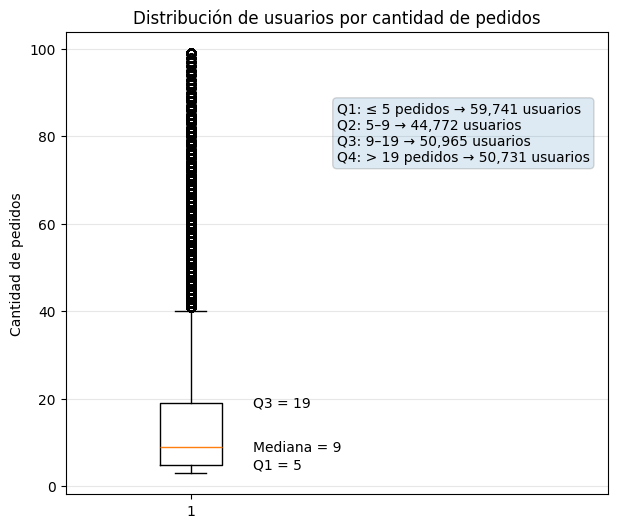

In [14]:
# Distribución de usuarios según la cantidad de pedidos

# Variable
x = orders_per_user["n_orders"]

# Cuartiles
q1 = x.quantile(0.25)
median = x.quantile(0.50)
q3 = x.quantile(0.75)

# Cantidad de usuarios en cada tramo
n_q1 = (x <= q1).sum()
n_q2 = ((x > q1) & (x <= median)).sum()
n_q3 = ((x > median) & (x <= q3)).sum()
n_q4 = (x > q3).sum()

# Boxplot
plt.figure(figsize=(7, 6))

plt.boxplot(x)

plt.ylabel("Cantidad de pedidos")
plt.title("Distribución de usuarios por cantidad de pedidos")
plt.grid(axis="y", alpha=0.3)

# Etiquetas de los cuartiles
plt.text(1.15, q1, f"Q1 = {q1:.0f}", va="center")
plt.text(1.15, median, f"Mediana = {median:.0f}", va="center")
plt.text(1.15, q3, f"Q3 = {q3:.0f}", va="center")

# Resumen de cantidad de usuarios por cuartil
texto = (
    f"Q1: ≤ {q1:.0f} pedidos → {n_q1:,} usuarios\n"
    f"Q2: {q1:.0f}–{median:.0f} → {n_q2:,} usuarios\n"
    f"Q3: {median:.0f}–{q3:.0f} → {n_q3:,} usuarios\n"
    f"Q4: > {q3:.0f} pedidos → {n_q4:,} usuarios"
)

plt.text(
    1.35,
    x.max() * 0.75,
    texto,
    fontsize=10,
    bbox=dict(boxstyle="round", alpha=0.15)
)

plt.xlim(0.7, 2)
plt.show()


In [15]:
## Tamaño de los carritos:

pd.options.display.float_format = '{:,.2f}'.format

cart_size = (
    data
    .groupby("order_id")
    .size()
    .reset_index(name="products_in_order") 
)

cart_size.products_in_order.describe()

count   3,214,874.00
mean           10.09
std             7.53
min             1.00
25%             5.00
50%             8.00
75%            14.00
max           145.00
Name: products_in_order, dtype: float64

entre 1 y 5 =  el percentil 25 es 5. Un cuarto de los pedidos no supera ese valor. 

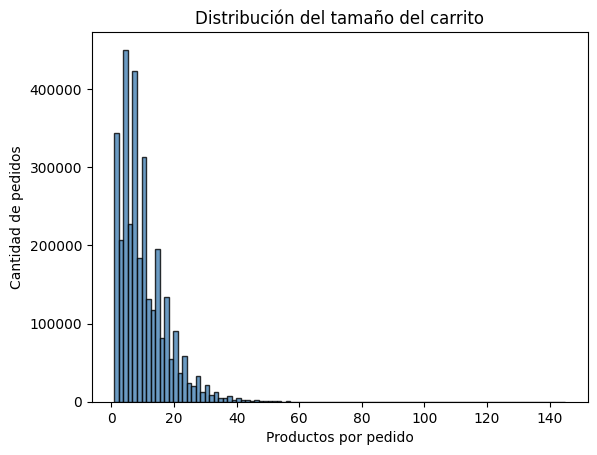

In [16]:
plt.figure()
plt.hist(
    cart_size["products_in_order"],
    bins=100,
    color="steelblue",
    edgecolor="black",
    alpha=0.8
)
plt.xlabel("Productos por pedido")
plt.ylabel("Cantidad de pedidos")
plt.title("Distribución del tamaño del carrito")
plt.show()

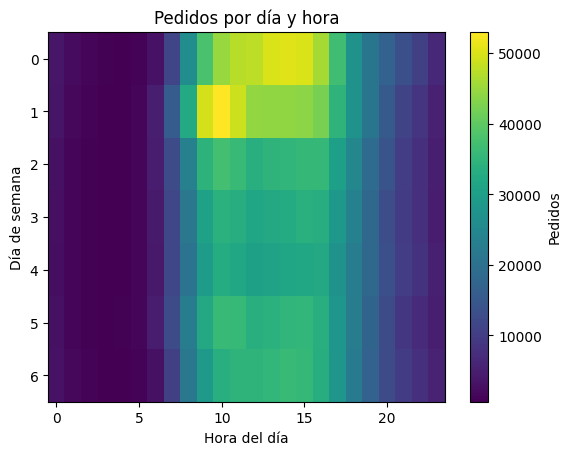

In [17]:
pivot = (
    data[["order_id", "order_dow", "order_hour_of_day"]]
    .drop_duplicates()
    .groupby(["order_dow", "order_hour_of_day"])
    .size()
    .reset_index(name="orders")
)

heat = pivot.pivot(
    index="order_dow",
    columns="order_hour_of_day",
    values="orders"
).fillna(0)

plt.figure()
plt.imshow(heat.values, aspect="auto")
plt.colorbar(label="Pedidos")
plt.xlabel("Hora del día")
plt.ylabel("Día de semana")
plt.title("Pedidos por día y hora")
plt.show()


In [18]:
mix_by_order = (
    data
    .groupby("order_id")["department"]
    .nunique()
    .reset_index(name="n_departments")
)

mix_by_order['n_departments'].describe()


count   3,214,874.00
mean            4.74
std             2.55
min             1.00
25%             3.00
50%             4.00
75%             6.00
max            18.00
Name: n_departments, dtype: float64

In [19]:
## N

mix_dist = (
    mix_by_order
    .groupby("n_departments")
    .size()
    .reset_index(name="orders")
    .sort_values("n_departments")
)


In [20]:
mix_dist["share_pct"] = (
    mix_dist["orders"] / mix_dist["orders"].sum() * 100
)

mix_dist

,n_departments,orders,share_pct
0,1,287948,8.96
1,2,395701,12.31
2,3,468955,14.59
3,4,488113,15.18
4,5,447455,13.92
5,6,367284,11.42
6,7,279920,8.71
7,8,198390,6.17
8,9,130101,4.05
9,10,78397,2.44


Interesante, saber que porcentaje ocupa cada mixicidad de categorias en los pedidos.  Vamos a ver que relación tiene con la fidelidad de los clientes. 

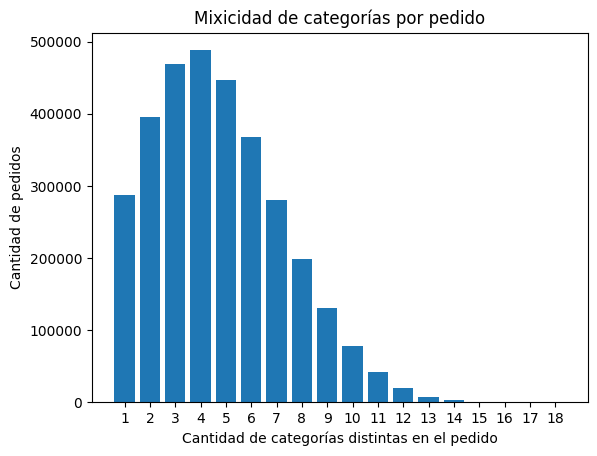

In [21]:
plt.figure()
plt.bar(mix_dist["n_departments"], mix_dist["orders"])
plt.xlabel("Cantidad de categorías distintas en el pedido")
plt.ylabel("Cantidad de pedidos")
plt.title("Mixicidad de categorías por pedido")
plt.xticks(mix_dist["n_departments"]) 
plt.show()


## 3.2 Volumen de pedidos y categorías


In [22]:
sales_by_category = (
    data.groupby("department")
    .agg(
        orders=("order_id", "nunique"),
        products_sold=("product_id", "count"),
        users=("user_id", "nunique")
    )
    .reset_index()
    .sort_values("products_sold", ascending=False)
)


In [23]:
total_orders = data["order_id"].nunique()

penetration = (
    data.groupby("department")["order_id"]
    .nunique()
    .div(total_orders) ## divido por total orders
    .mul(100) # paso a porcentaje
    .reset_index(name="order_penetration_pct")
)


### Penetración de categorías


In [24]:
penetration.sort_values("order_penetration_pct", ascending=False)

,department,order_penetration_pct
19,produce,74.94
7,dairy eggs,67.73
3,beverages,45.33
20,snacks,43.28
10,frozen,36.74
16,pantry,34.77
2,bakery,27.42
8,deli,23.96
6,canned goods,21.19
9,dry goods pasta,18.60


### Tasa de recompra por categoría


In [25]:
reorder_rate = (
    data.groupby("department")["reordered"]
    .mean()
    .mul(100)
    .reset_index(name="reorder_rate_pct")
)


In [26]:
reorder_rate.sort_values("reorder_rate_pct", ascending=False)

,department,reorder_rate_pct
7,dairy eggs,67.00
3,beverages,65.35
19,produce,64.99
2,bakery,62.81
8,deli,60.77
18,pets,60.13
1,babies,57.90
5,bulk,57.70
20,snacks,57.42
0,alcohol,56.99


In [27]:
### Qué productos se compran más veces? 

product_profile = (
    data.groupby(['product_id', 'product_name', 'department'])
      .agg(
          total_purchases=('order_id', 'count'),
          unique_buyers=('user_id', 'nunique'),
          reorder_rate=('reordered', 'mean')
        #   revenue=('final_price', 'sum'),
        #   total_margin=('final_margin', 'sum'),
        #   avg_price=('final_price', 'mean'),
        #   avg_discount=('discount_pct', 'mean')
      )
      .reset_index()
)

total_users = data['user_id'].nunique()

product_profile['penetracion_users'] = (
    product_profile['unique_buyers'] / total_users
)

product_profile['compras_total'] = (
    product_profile['total_purchases']

)


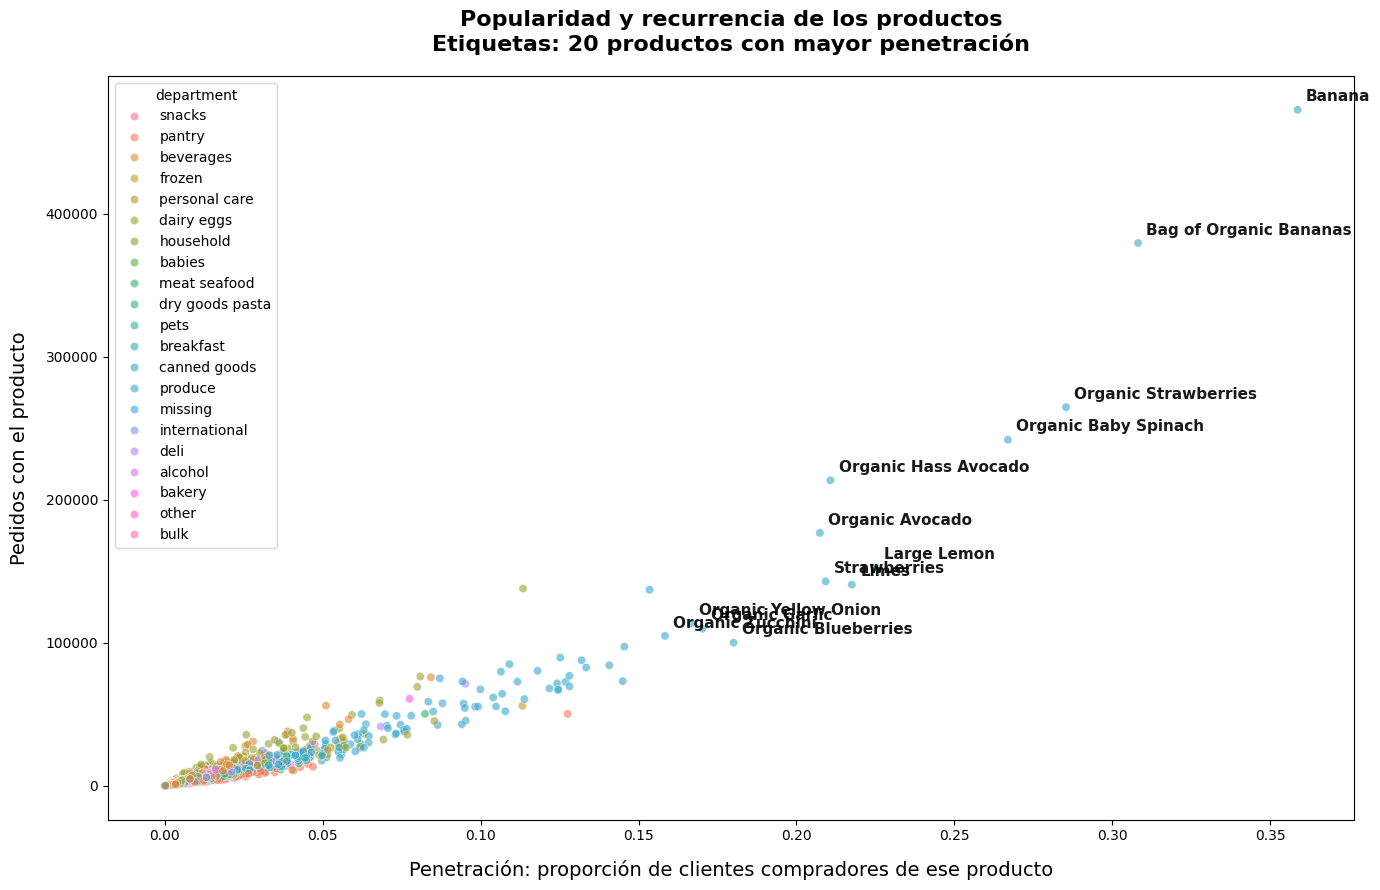

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

top_20 = product_profile.nlargest(13, 'penetracion_users')

plt.figure(figsize=(14, 9))

ax = sns.scatterplot(
    data=product_profile,
    x='penetracion_users',
    y='compras_total',
    hue='department',
    sizes=(20, 400),
    alpha=0.6
)

# Nombres de los 20 productos
for _, row in top_20.iterrows():
    ax.annotate(
        row['product_name'],
        xy=(
            row['penetracion_users'],
            row['compras_total']
        ),
        xytext=(6, 6),
        textcoords='offset points',
        fontsize=11,          # tamaño del nombre del producto
        fontweight='bold',
        alpha=0.9
    )

# Etiquetas de los ejes
ax.set_xlabel(
    'Penetración: proporción de clientes compradores de ese producto',
    fontsize=14,
    labelpad=12
)

ax.set_ylabel(
    'Pedidos con el producto',
    fontsize=14,
    labelpad=12
)

# Título
ax.set_title(
    'Popularidad y recurrencia de los productos\n'
    'Etiquetas: 20 productos con mayor penetración',
    fontsize=16,
    fontweight='bold',
    pad=18
)

# Números de los ejes
ax.tick_params(
    axis='both',
    labelsize=10
)

plt.tight_layout()
plt.show()

### Frecuencia de compra de los usuarios


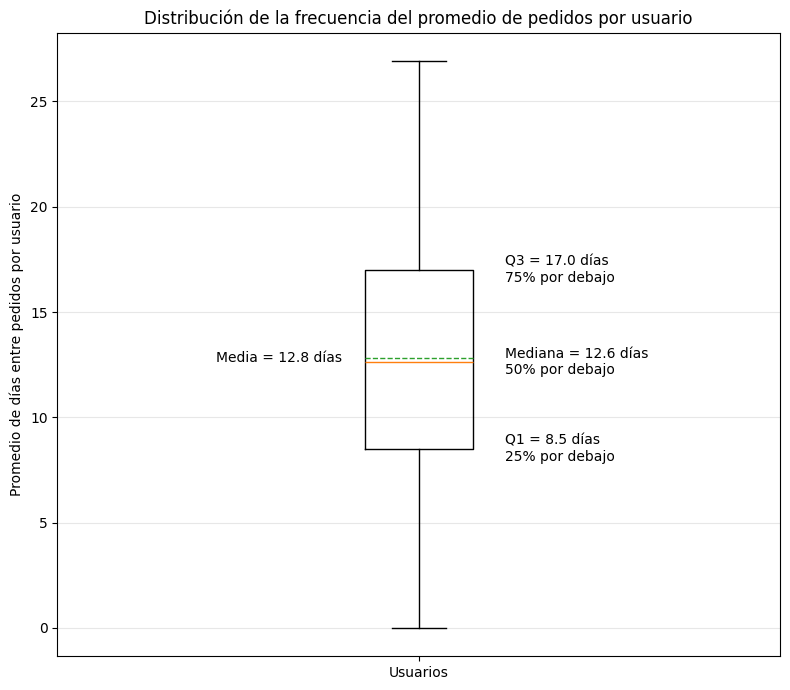

In [29]:
# hist cumulative percentage

import matplotlib.pyplot as plt
import numpy as np

avg_days_between_orders = (
    orders.groupby("user_id")["days_since_prior_order"]
    .mean()
    .reset_index(name="avg_days_between_orders")
)
dat = avg_days_between_orders['avg_days_between_orders'].dropna()

q1 = dat.quantile(0.25)
median = dat.quantile(0.50)
q3 = dat.quantile(0.75)
mean = dat.mean()

plt.figure(figsize=(8, 7))

plt.boxplot(
    dat,
    showmeans=True,
    meanline=True
)

# Etiquetas de cuartiles
plt.annotate(
    f'Q1 = {q1:.1f} días\n25% por debajo',
    xy=(1, q1),
    xytext=(1.12, q1),
    va='center'
)

plt.annotate(
    f'Mediana = {median:.1f} días\n50% por debajo',
    xy=(1, median),
    xytext=(1.12, median),
    va='center'
)

plt.annotate(
    f'Q3 = {q3:.1f} días\n75% por debajo',
    xy=(1, q3),
    xytext=(1.12, q3),
    va='center'
)

plt.annotate(
    f'Media = {mean:.1f} días',
    xy=(1, mean),
    xytext=(0.72, mean),
    va='center'
)

plt.title('Distribución de la frecuencia del promedio de pedidos por usuario')
plt.xticks([1], ['Usuarios'])
plt.xlabel('')
plt.ylabel('Promedio de días entre pedidos por usuario')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 4. Split temporal Train / Validation / Test 

Para reproducir el problema de **next-basket prediction**, se reservan los últimos tres momentos temporales de cada usuario:

- historial hasta `n-3` → features de Train;
- pedido `n-2` → target de Train;
- historial hasta `n-2` → features de Validation;
- pedido `n-1` → target de Validation;
- historial hasta `n-1` → features de Test;
- pedido `n` → Test final.

La elegibilidad de usuarios se calcula exclusivamente con `history_train`, para no utilizar información futura.


In [30]:
# ============================================================
# SPLIT TEMPORAL: TRAIN / VALIDATION / TEST
# ============================================================

data["max_order_number"] = (
    data.groupby("user_id")["order_number"]
    .transform("max")
)

# ------------------------------------------------------------
# TRAIN
# Features con información hasta n-3
# Target = pedido n-2
# ------------------------------------------------------------

history_train = data[
    data["order_number"] <= data["max_order_number"] - 3
].copy()

train_target = data[
    data["order_number"] == data["max_order_number"] - 2
].copy()


# ------------------------------------------------------------
# VALIDATION
# Features con información hasta n-2
# Target = pedido n-1
# ------------------------------------------------------------

history_valid = data[
    data["order_number"] <= data["max_order_number"] - 2
].copy()

valid_target = data[
    data["order_number"] == data["max_order_number"] - 1
].copy()


# ------------------------------------------------------------
# TEST FINAL
# Target = pedido n
# ------------------------------------------------------------
# Para ahorrar RAM, NO construimos history_test todavía.
# Se construirá recién al final, después de liberar Train y Validation.

test = data[
    data["order_number"] == data["max_order_number"]
].copy()

# ------------------------------------------------------------
# 3. Aplicar filtro de usuarios a las tres particiones
# ------------------------------------------------------------
history_orders_train = (
    history_train[
        [
            "user_id",
            "order_id",
            "order_number",
            "days_since_prior_order"
        ]
    ]
    .drop_duplicates(["user_id", "order_id"])
)

user_frequency = (
        history_orders_train[
        history_orders_train["order_number"] > 1
    ]
    .groupby("user_id", as_index=False)
    .agg(
        avg_days_between_orders=(
            "days_since_prior_order",
            "mean"
        ),
        valid_interval=(
            "days_since_prior_order",
            "count"
        )
    )
)

eligible_users = user_frequency.loc[
    (user_frequency["avg_days_between_orders"] <= 35)
    & (user_frequency["valid_interval"] >= 1),
    "user_id"
]

history_train = history_train[
    history_train["user_id"].isin(eligible_users)
].copy()

train_target = train_target[
    train_target["user_id"].isin(eligible_users)
].copy()

history_valid = history_valid[
    history_valid["user_id"].isin(eligible_users)
].copy()

valid_target = valid_target[
    valid_target["user_id"].isin(eligible_users)
].copy()

test = test[
    test["user_id"].isin(eligible_users)
].copy()




print("Usuarios originales:", data["user_id"].nunique())
print("Usuarios elegibles:", eligible_users.nunique())
print(
    "Porcentaje conservado:",
    eligible_users.nunique() / data["user_id"].nunique()
)


Usuarios originales: 206209
Usuarios elegibles: 162633
Porcentaje conservado: 0.7886804164706681


# 5. Pipeline reutilizable de features por split

A partir de este punto, todo el feature engineering se encapsula en una única función: `build_model_table(history_snapshot)`.

La función recibe exclusivamente el historial disponible hasta el cutoff temporal de cada snapshot y reconstruye, sin mirar pedidos futuros:

- perfil de clientes y similitud entre usuarios;
- señales colaborativas de vecinos;
- popularidad global;
- candidatos;
- Market Basket Analysis;
- asociación con último carrito;
- asociación con productos core del usuario;
- features usuario–producto de frecuencia, recencia y cadencia;
- tabla final de features.

Esto evita duplicar código y garantiza que Train, Validation y Test utilicen exactamente la misma lógica.


In [31]:
def build_model_table(history_snapshot, return_audit=False):
    """
    Construye candidatos y todas las features utilizando exclusivamente
    la información disponible en un snapshot histórico.

    Parámetros
    ----------
    history_snapshot : pd.DataFrame
        Historial disponible hasta el cutoff temporal del snapshot.

    Retorna
    -------
    model_table : pd.DataFrame
        Una fila por user_id-product_id candidato con todas las features.
    """

    # ================================================================
    # PERFIL DE COMPORTAMIENTO DE LOS USUARIOS
    # Se utiliza únicamente history, sin incluir el último pedido/test
    # ================================================================

    import numpy as np
    import pandas as pd
    import gc
    from sklearn.preprocessing import StandardScaler
    from sklearn.neighbors import NearestNeighbors


    # ---------------------------------------------------------------
    # 1. CALCULAR CANTIDAD DE PRODUCTOS POR PEDIDO
    # ---------------------------------------------------------------
    #
    # Primero trabajamos a nivel user_id - order_id.
    # Queremos saber cuántos productos distintos tuvo cada pedido.
    # ---------------------------------------------------------------

    products_per_order_user = (
        history_snapshot
        .groupby(
            ['user_id', 'order_id'],
            as_index=False
        )
        .agg(
            products_in_order=('product_id', 'nunique')
        )
    )


    # ---------------------------------------------------------------
    # 2. CALCULAR PROMEDIO DE PRODUCTOS POR PEDIDO Y USUARIO
    # ---------------------------------------------------------------

    avg_products_per_user = (
        products_per_order_user
        .groupby(
            'user_id',
            as_index=False
        )
        .agg(
            avg_products_per_order_user=(
                'products_in_order',
                'mean'
            )
        )
    )


    # ---------------------------------------------------------------
    # 3. CALCULAR PERFIL GENERAL DEL USUARIO
    # ---------------------------------------------------------------
    #
    # Cant_de_pedidos:
    # cantidad de pedidos históricos distintos.
    #
    # avg_days_between_orders:
    # cantidad promedio de días entre pedidos.
    #
    # std_days_between_orders:
    # variabilidad del intervalo entre pedidos.
    # ---------------------------------------------------------------

    customer_rfm = (
        history_snapshot
        .groupby('user_id')
        .agg(
            Cant_de_pedidos=(
                'order_id',
                'nunique'
            ),

            avg_days_between_orders=(
                'days_since_prior_order',
                'mean'
            ),

            std_days_between_orders=(
                'days_since_prior_order',
                'std'
            )
        )
        .reset_index()
    )


    # ---------------------------------------------------------------
    # 4. AGREGAR PROMEDIO DE PRODUCTOS POR PEDIDO
    # ---------------------------------------------------------------

    customer_rfm = customer_rfm.merge(
        avg_products_per_user,
        on='user_id',
        how='left'
    )


    # ---------------------------------------------------------------
    # 5. ORDENAR COLUMNAS
    # ---------------------------------------------------------------

    customer_rfm = customer_rfm[
        [
            'user_id',
            'avg_days_between_orders',
            'std_days_between_orders',
            'avg_products_per_order_user',
            'Cant_de_pedidos'
        ]
    ].copy()

    # Ya no necesitamos estas tablas intermedias.
    del products_per_order_user
    del avg_products_per_user
    gc.collect()


    # ---------------------------------------------------------------
    # 6. REVISAR DISTRIBUCIONES
    # ---------------------------------------------------------------

    print(
        customer_rfm[
            [
                'avg_days_between_orders',
                'std_days_between_orders',
                'avg_products_per_order_user',
                'Cant_de_pedidos'
            ]
        ].describe()
    )


    # ---------------------------------------------------------------
    # 7. TRATAR NaN
    # ---------------------------------------------------------------
    #
    # std_days_between_orders puede ser NaN si no existen suficientes
    # intervalos para calcular una desviación estándar.
    # ---------------------------------------------------------------

    customer_rfm[
        'std_days_between_orders'
    ] = customer_rfm[
        'std_days_between_orders'
    ].fillna(0)


    # ---------------------------------------------------------------
    # 8. SUAVIZAR DISTRIBUCIONES CON LOG1P
    # ---------------------------------------------------------------

    customer_rfm['Cant_de_pedidos_log'] = np.log1p(
        customer_rfm['Cant_de_pedidos']
    )

    customer_rfm['avg_days_between_orders_log'] = np.log1p(
        customer_rfm['avg_days_between_orders']
    )

    customer_rfm['std_days_between_orders_log'] = np.log1p(
        customer_rfm['std_days_between_orders']
    )

    customer_rfm['avg_products_per_order_user_log'] = np.log1p(
        customer_rfm['avg_products_per_order_user']
    )


    # ---------------------------------------------------------------
    # 9. ESTANDARIZAR VARIABLES
    # ---------------------------------------------------------------

    rfm_features = [
        'avg_days_between_orders_log',
        'std_days_between_orders_log',
        'avg_products_per_order_user_log',
        'Cant_de_pedidos_log'
    ]

    scaler_rfm = StandardScaler()

    X_rfm = scaler_rfm.fit_transform(
        customer_rfm[rfm_features]
    )


    # ---------------------------------------------------------------
    # 10. BUSCAR VECINOS
    # ---------------------------------------------------------------

    k_rfm_neighbors = 20

    knn_rfm = NearestNeighbors(
        n_neighbors=k_rfm_neighbors + 1,
        metric='euclidean',
        algorithm='auto',
        n_jobs=-1
    )

    knn_rfm.fit(X_rfm)

    rfm_distances, rfm_indices = knn_rfm.kneighbors(
        X_rfm
    )


    # ---------------------------------------------------------------
    # 11. CREAR TABLA DE VECINOS
    # ---------------------------------------------------------------

    user_ids_rfm = customer_rfm[
        'user_id'
    ].to_numpy()

    distances_without_self = rfm_distances[:, 1:]
    indices_without_self = rfm_indices[:, 1:]

    rfm_neighbors = pd.DataFrame({

        'user_id': np.repeat(
            user_ids_rfm,
            k_rfm_neighbors
        ),

        'neighbor_user_id': user_ids_rfm[
            indices_without_self.ravel()
        ],

        'rfm_neighbor_rank': np.tile(
            np.arange(
                1,
                k_rfm_neighbors + 1
            ),
            len(user_ids_rfm)
        ),

        'rfm_distance':
            distances_without_self.ravel()
    })


    # ---------------------------------------------------------------
    # 12. CONVERTIR DISTANCIA EN SCORE DE SIMILITUD
    # ---------------------------------------------------------------

    rfm_neighbors['rfm_similarity'] = (
        1 / (
            1 +
            rfm_neighbors['rfm_distance']
        )
    )


    # ---------------------------------------------------------------
    # 13. REVISAR RESULTADOS
    # ---------------------------------------------------------------

    print(
        rfm_neighbors[
            'rfm_similarity'
        ].describe()
    )

    # Ya no necesitamos los objetos utilizados para calcular los vecinos RFM.
    del X_rfm
    del scaler_rfm
    del knn_rfm
    del rfm_distances
    del rfm_indices
    del distances_without_self
    del indices_without_self
    gc.collect()

    # ================================================================
    # SIMILITUD ENTRE CLIENTES SEGÚN PRODUCTOS COMPRADOS
    # ================================================================
    #
    # Objetivo:
    # Encontrar clientes con historiales de productos similares,
    # considerando:
    #
    # 1. Qué productos compró cada cliente.
    # 2. Cuántas veces compró cada producto.
    # 3. Qué tan popular es cada producto globalmente.
    #
    # La idea es:
    #
    # - Dar más peso a productos comprados varias veces por un usuario.
    # - Evitar que productos extremadamente populares hagan parecer
    #   similares a todos los clientes.
    # - Trabajar con matrices dispersas para no consumir demasiada memoria.
    #
    # IMPORTANTE:
    # Se utiliza únicamente `history`, que debe excluir el último pedido
    # reservado para test.
    #
    # Resultado final:
    # `product_neighbors`
    #
    # Columnas:
    # - user_id
    # - neighbor_user_id
    # - product_neighbor_rank
    # - product_distance
    # - product_similarity
    # ================================================================


    # ---------------------------------------------------------------
    # 0. IMPORTACIONES
    # ---------------------------------------------------------------

    import numpy as np
    import pandas as pd

    from scipy.sparse import csr_matrix
    from sklearn.preprocessing import normalize
    from sklearn.neighbors import NearestNeighbors


    # ---------------------------------------------------------------
    # 1. CONFIGURACIÓN
    # ---------------------------------------------------------------

    # Cantidad de vecinos similares que queremos obtener por usuario.
    # Empezamos con 10 para mantener el cálculo manejable.
    k_product_neighbors = 10

    # Cantidad de usuarios a procesar en cada bloque.
    # Evita consultar los 206.000 usuarios al mismo tiempo.
    batch_size = 5000


    # ---------------------------------------------------------------
    # 3. FRECUENCIA DE COMPRA POR USUARIO Y PRODUCTO
    # ---------------------------------------------------------------
    #
    # Cada fila indica cuántos pedidos diferentes de un usuario
    # incluyeron un determinado producto.
    #
    # Usamos nunique(order_id) porque:
    #
    # - La tabla original está a nivel producto-pedido.
    # - Queremos contar apariciones en pedidos.
    # - Evitamos contar duplicados accidentales dentro del mismo pedido.
    # ---------------------------------------------------------------

    user_product_frequency = (
        history_snapshot
        .groupby(
            ['user_id', 'product_id'],
            as_index=False
        )
        .agg(
            purchase_count=('order_id', 'nunique')
        )
    )


    # ---------------------------------------------------------------
    # 4. CREAR ÍNDICES INTERNOS PARA USUARIOS Y PRODUCTOS
    # ---------------------------------------------------------------
    #
    # Las matrices dispersas necesitan posiciones numéricas:
    #
    # user_idx:
    # posición de cada usuario dentro de la matriz.
    #
    # product_idx:
    # posición de cada producto dentro de la matriz.
    # ---------------------------------------------------------------

    user_ids = np.sort(
        user_product_frequency['user_id'].unique()
    )

    product_ids = np.sort(
        user_product_frequency['product_id'].unique()
    )

    user_to_index = {
        user_id: index
        for index, user_id in enumerate(user_ids)
    }

    product_to_index = {
        product_id: index
        for index, product_id in enumerate(product_ids)
    }

    user_product_frequency['user_idx'] = (
        user_product_frequency['user_id']
        .map(user_to_index)
    )

    user_product_frequency['product_idx'] = (
        user_product_frequency['product_id']
        .map(product_to_index)
    )


    # ---------------------------------------------------------------
    # 5. CREAR MATRIZ DISPERSA USUARIO-PRODUCTO
    # ---------------------------------------------------------------
    #
    # Filas:
    # usuarios.
    #
    # Columnas:
    # productos.
    #
    # Valores:
    # cantidad de pedidos donde el usuario compró el producto.
    #
    # Usamos csr_matrix porque una matriz usuario-producto suele tener
    # una gran cantidad de ceros.
    #
    # No conviene usar pivot_table con 206.000 usuarios porque podría
    # crear una matriz densa demasiado grande.
    # ---------------------------------------------------------------

    user_product_matrix = csr_matrix(
        (
            user_product_frequency['purchase_count'].astype(float),
            (
                user_product_frequency['user_idx'],
                user_product_frequency['product_idx']
            )
        ),
        shape=(
            len(user_ids),
            len(product_ids)
        )
    )


    # ---------------------------------------------------------------
    # 6. TF - SUAVIZAR LA FRECUENCIA CON LOG1P
    # ---------------------------------------------------------------
    #
    # Sin transformación:
    #
    # - 1 compra  = peso 1
    # - 10 compras = peso 10
    #
    # Eso puede hacer que usuarios o productos muy repetidos dominen
    # completamente la similitud.
    #
    # TF:
    # frecuencia suavizada de compra del usuario-producto.
    # Con log1p:
    #
    # - Se mantiene la información de intensidad.
    # - Se reduce el peso de valores extremos.
    #
    # log1p(x) = log(1 + x)
    # ---------------------------------------------------------------



    user_product_matrix.data = np.log1p(
        user_product_matrix.data
    )


    # ---------------------------------------------------------------
    # 7. CALCULAR POPULARIDAD GLOBAL DE CADA PRODUCTO
    # ---------------------------------------------------------------
    #
    # Contamos cuántos usuarios diferentes compraron cada producto.
    #
    # Esto se utiliza para reducir el peso de productos extremadamente
    # populares, que no diferencian bien entre usuarios.
    # ---------------------------------------------------------------

    product_user_count = np.asarray(
        (user_product_matrix > 0).sum(axis=0)
    ).ravel()

    n_users = user_product_matrix.shape[0]


    # ---------------------------------------------------------------
    # 8. CALCULAR IDF
    # ---------------------------------------------------------------
    #
    # IDF significa Inverse Document Frequency.
    #
    # Adaptado al problema:
    #
    # - "Documento" = usuario.
    # - "Palabra" = producto.
    #
    # Si un producto lo compran casi todos los usuarios:
    # tendrá un IDF menor.
    #
    # Si un producto lo compran pocos usuarios:
    # tendrá un IDF mayor.
    #
    # La suma de 1 evita divisiones por cero.
    # ---------------------------------------------------------------

    idf = (
        np.log(
            (1 + n_users)
            /
            (1 + product_user_count)
        )
        + 1
    )


    # ---------------------------------------------------------------
    # 9. APLICAR PONDERACIÓN IDF
    # ---------------------------------------------------------------
    #
    # IDF:
    # importancia inversa según popularidad global.
    #
    # De esta manera:
    #
    # - Los productos comprados muchas veces por el usuario pesan más.
    # - Los productos comprados por casi todo el mundo pesan menos.
    # - Los productos característicos del cliente pesan más.
    # ---------------------------------------------------------------

    user_product_tfidf = (
        user_product_matrix
        .multiply(idf)
        .tocsr()
    )

    # ---------------------------------------------------------------
    # 10.A. NORMALIZAR CADA USUARIO
    # ---------------------------------------------------------------
    #
    # La normalización L2 hace que la longitud del vector de cada usuario
    # sea igual a 1.
    #
    # Esto permite comparar el patrón relativo de productos y no solamente
    # la cantidad total de compras.
    #
    # Después de normalizar, el producto escalar entre dos usuarios
    # equivale a la similitud coseno.
    # ---------------------------------------------------------------

    user_product_tfidf = normalize(
        user_product_tfidf,
        norm='l2',
        axis=1
    ).tocsr()


    # ---------------------------------------------------------------
    # 11. CONFIGURAR EL MODELO DE VECINOS
    # ---------------------------------------------------------------
    #
    # Usamos distancia coseno:
    #
    # distancia_coseno = 1 - similitud_coseno
    #
    # Por lo tanto:
    #
    # similitud_coseno = 1 - distancia_coseno
    #
    # Usamos k + 1 vecinos porque el primer vecino suele ser
    # el propio usuario, con distancia 0.
    #
    # algorithm='brute':
    # es adecuado para matrices dispersas y similitud coseno.
    #
    # n_jobs=-1:
    # usa todos los núcleos disponibles.
    # ---------------------------------------------------------------

    knn_products = NearestNeighbors(
        n_neighbors=k_product_neighbors + 1,
        metric='cosine',
        algorithm='brute',
        n_jobs=-1
    )

    knn_products.fit(
        user_product_tfidf
    )


    # ---------------------------------------------------------------
    # 12. BUSCAR VECINOS POR BLOQUES
    # ---------------------------------------------------------------
    #
    # No consultamos todos los usuarios simultáneamente.
    #
    # Procesamos por bloques para reducir el uso máximo de memoria.
    #
    # IMPORTANTE:
    # Aunque la matriz sea dispersa, la búsqueda exacta con brute force
    # puede ser costosa con más de 200.000 usuarios.
    # Para una primera prueba puede convenir ejecutar esto sobre una
    # muestra o reducir temporalmente la cantidad de usuarios.
    # ---------------------------------------------------------------

    neighbor_tables = []

    for start in range(
        0,
        len(user_ids),
        batch_size
    ):

        end = min(
            start + batch_size,
            len(user_ids)
        )

        distances_batch, indices_batch = (
            knn_products.kneighbors(
                user_product_tfidf[start:end],
                return_distance=True
            )
        )

        # -----------------------------------------------------------
        # 13. CONVERTIR EL RESULTADO DEL BLOQUE EN UNA TABLA
        # -----------------------------------------------------------
        #
        # distances_batch:
        # distancia coseno entre el usuario y cada vecino.
        #
        # indices_batch:
        # posición matricial de los vecinos encontrados.
        #
        # Normalmente la posición 0 corresponde al propio usuario.
        # La excluimos usando [:, 1:].
        # -----------------------------------------------------------

        batch_user_ids = user_ids[start:end]

        distances_without_self = distances_batch[:, 1:]
        indices_without_self = indices_batch[:, 1:]

        n_batch_users = len(batch_user_ids)

        batch_table = pd.DataFrame({
            'user_id': np.repeat(
                batch_user_ids,
                k_product_neighbors
            ),

            'neighbor_user_id': user_ids[
                indices_without_self.ravel()
            ],

            'product_neighbor_rank': np.tile(
                np.arange(
                    1,
                    k_product_neighbors + 1
                ),
                n_batch_users
            ),

            'product_distance': (
                distances_without_self.ravel()
            )
        })

        # Convertimos distancia coseno en similitud.
        #
        # Valores cercanos a 1:
        # historiales de productos muy similares.
        #
        # Valores cercanos a 0:
        # historiales con poca similitud.
        batch_table['product_similarity'] = (
            1 - batch_table['product_distance']
        )

        neighbor_tables.append(
            batch_table
        )

        print(
            f'Usuarios procesados: {end:,} '
            f'de {len(user_ids):,}'
        )


    # ---------------------------------------------------------------
    # 14. UNIR TODOS LOS BLOQUES
    # ---------------------------------------------------------------

    product_neighbors = pd.concat(
        neighbor_tables,
        ignore_index=True
    )

    # La tabla final ya está unida; liberamos los bloques individuales.
    del neighbor_tables
    gc.collect()


    # ---------------------------------------------------------------
    # 15. ORDENAR EL RESULTADO
    # ---------------------------------------------------------------

    product_neighbors = (
        product_neighbors
        .sort_values(
            [
                'user_id',
                'product_neighbor_rank'
            ]
        )
        .reset_index(drop=True)
    )


    # ---------------------------------------------------------------
    # 16. VALIDACIONES DEL RESULTADO
    # ---------------------------------------------------------------

    expected_rows = (
        len(user_ids)
        * k_product_neighbors
    )

    print('\n================ RESULTADO ================')

    print(
        f'Usuarios analizados: '
        f'{len(user_ids):,}'
    )

    print(
        f'Productos analizados: '
        f'{len(product_ids):,}'
    )

    print(
        f'Interacciones usuario-producto: '
        f'{len(user_product_frequency):,}'
    )

    print(
        f'Filas esperadas en product_neighbors: '
        f'{expected_rows:,}'
    )

    print(
        f'Filas obtenidas en product_neighbors: '
        f'{len(product_neighbors):,}'
    )

    print('\nResumen de similitud:')

    print(
        product_neighbors[
            'product_similarity'
        ].describe()
    )



    # ================================================================
    # OBJETOS PRINCIPALES OBTENIDOS
    # ================================================================
    #
    # user_product_frequency
    # ----------------------
    # Frecuencia histórica de compra por usuario-producto.
    #
    # user_product_matrix
    # -------------------
    # Matriz dispersa con frecuencias suavizadas.
    #
    # user_product_tfidf
    # ------------------
    # Matriz usuario-producto ponderada y normalizada.
    #
    # product_neighbors
    # -----------------
    # Tabla final con los vecinos más similares por productos.
    #
    # La tabla `product_neighbors` será utilizada posteriormente para:
    #
    # 1. Extraer productos comprados por clientes similares.
    # 2. Generar candidatos de productos por usuario.
    # 3. Crear features para LightGBM, por ejemplo:
    #
    #    - cantidad de vecinos que compraron el producto;
    #    - similitud promedio de los vecinos compradores;
    #    - similitud máxima de un vecino comprador;
    #    - score ponderado de compra entre vecinos.
    #
    # Todavía no estamos generando candidatos.
    # Este paso solamente define y calcula similitud por productos.
    # ================================================================

    # Agrego a product_neighbors los product_id, que compraron sus 10 vecinos más similares, para cada usuario. Esto me permite ver qué productos compraron los vecinos de cada usuario.   
    neighbor_products = (
        product_neighbors
        .merge(
            history_snapshot[
                ['user_id', 'product_id']
            ].drop_duplicates(),
            left_on='neighbor_user_id',
            right_on='user_id',
            suffixes=('', '_neighbor')
        )
        .drop(columns='user_id_neighbor')
    )

    neighbor_product_scores = (
        neighbor_products
        .groupby(
            ['user_id', 'product_id'],
            as_index=False
        )
        .agg(
            neighbor_buyers=(
                'neighbor_user_id',
                'nunique'
            ),
            neighbor_similarity_sum=(
                'product_similarity',
                'sum'
            ),
            neighbor_similarity_max=(
                'product_similarity',
                'max'
            ),
            neighbor_similarity_mean=(
                'product_similarity',
                'mean'
            )
        )
    )

    # Liberamos los objetos grandes que ya no se necesitan para generar features.
    del neighbor_products
    del user_product_frequency
    del user_product_matrix
    del user_product_tfidf
    del knn_products
    del product_user_count
    del idf
    del user_to_index
    del product_to_index

    # En Train no necesitamos conservar las tablas de vecinos para auditoría.
    if not return_audit:
        del rfm_neighbors
        del product_neighbors

    gc.collect()

    print('Intermedios KNN liberados.')

    ## Popularidad global de productos

    global_popularity = (
        history_snapshot
        .groupby('product_id')
        .agg(
            global_unique_buyers=('user_id', 'nunique'),
            global_purchase_count=('order_id', 'nunique')
        )
        .reset_index()
        .sort_values(
            'global_unique_buyers',
            ascending=False
        )
    )

    top_n_global = 50

    popular_products = (
        global_popularity
        .head(top_n_global)['product_id']
    )

    # Producto comprado en el History del usuario
    productos_candidatos = (
        history_snapshot[
            ['user_id', 'product_id']
        ]
        .drop_duplicates()
        .copy()
    )

    productos_candidatos['source_previous'] = 1

    top_n_neighbor_products = 50

    neighbor_candidates = (
        neighbor_product_scores
        .sort_values(
            [
                'user_id',
                'neighbor_similarity_sum'
            ],
            ascending=[True, False]
        )
        .groupby('user_id')
        .head(top_n_neighbor_products)
        .copy()
    )

    neighbor_candidates['source_similar_users'] = 1

    ## Combinamos esos productos con todos los usuarios elegibles:

    eligible_user_ids = (
        history_snapshot['user_id']
        .drop_duplicates()
        .to_frame()
    )

    popular_candidates = (
        eligible_user_ids
        .assign(key=1)
        .merge(
            popular_products
            .to_frame()
            .assign(key=1),
            on='key'
        )
        .drop(columns='key')
    )

    popular_candidates['source_global_popular'] = 1

    ### Unir las 3 fuentes:

    previous_for_union = productos_candidatos[
        [
            'user_id',
            'product_id',
            'source_previous'
        ]
    ]

    neighbor_for_union = neighbor_candidates[
        [
            'user_id',
            'product_id',
            'source_similar_users'
        ]
    ]

    popular_for_union = popular_candidates[
        [
            'user_id',
            'product_id',
            'source_global_popular'
        ]
    ]

    candidates = pd.concat(
        [
            previous_for_union,
            neighbor_for_union,
            popular_for_union
        ],
        ignore_index=True
    )


    ### Como un producto puede provenir de más de una fuente, agrupamos:

    candidates = (
        candidates
        .fillna(0)
        .groupby(
            ['user_id', 'product_id'],
            as_index=False
        )
        .agg(
            source_previous=('source_previous', 'max'),
            source_similar_users=('source_similar_users', 'max'),
            source_global_popular=('source_global_popular', 'max')
        )
    )

    # Las variables de origen ya están resumidas dentro de candidates.
    del productos_candidatos
    del neighbor_candidates
    del popular_candidates
    del previous_for_union
    del neighbor_for_union
    del popular_for_union
    del eligible_user_ids
    del popular_products
    gc.collect()

    print(f'Candidatos construidos: {len(candidates):,}')

    # ================================================================
    # PRODUCTOS QUE SE COMPRAN JUNTOS
    # ================================================================
    #
    # Se utiliza únicamente `history`.
    #
    # Cada par representa dos productos que aparecieron dentro
    # del mismo pedido.
    #
    # Métricas:
    #
    # pair_orders:
    # cantidad de pedidos que contienen ambos productos.
    #
    # support:
    # proporción de todos los pedidos que contiene el par.
    #
    # confidence_a_b:
    # P(B | A): de los pedidos con A, qué porcentaje también contiene B.
    #
    # confidence_b_a:
    # P(A | B): de los pedidos con B, qué porcentaje también contiene A.
    #
    # lift:
    # cuánto más aparecen juntos de lo esperado por azar.
    #
    # lift > 1  → asociación positiva.
    # lift = 1  → independencia aproximada.
    # lift < 1  → aparecen juntos menos de lo esperado.
    # ================================================================

    import pandas as pd
    import numpy as np
    from itertools import combinations
    from collections import Counter


    # ---------------------------------------------------------------
    # 3. INFORMACIÓN GENERAL
    # ---------------------------------------------------------------

    total_orders = history_snapshot['order_id'].nunique()

    product_order_count = (
        history_snapshot
        .groupby('product_id')['order_id']
        .nunique()
        .rename('product_orders')
    )

    print(f'Pedidos históricos: {total_orders:,}')
    print(f'Productos históricos: {history_snapshot["product_id"].nunique():,}')


    # ---------------------------------------------------------------
    # 4. CREAR LOS PARES DENTRO DE CADA PEDIDO
    # ---------------------------------------------------------------
    #
    # Para un pedido con:
    #
    # [A, B, C]
    #
    # se crean:
    #
    # (A, B)
    # (A, C)
    # (B, C)
    #
    # Ordenamos los product_id para que:
    #
    # (A, B) y (B, A)
    #
    # sean considerados el mismo par.
    # ---------------------------------------------------------------

    pair_counter = Counter()

    ## Crea el set de productos únicos por order_id.
    products_by_order = (
        history_snapshot
        .groupby('order_id')['product_id']
        .apply(lambda products: sorted(set(products)))
    )

    for products in products_by_order:

        # Un pedido con un solo producto no genera pares
        if len(products) < 2:
            continue

        pair_counter.update(
            combinations(products, 2)
        )

    # Ya contamos todos los pares; no necesitamos mantener la serie de pedidos.
    del products_by_order
    gc.collect()


    # ---------------------------------------------------------------
    # 5. CONVERTIR LOS PARES EN DATAFRAME
    # ---------------------------------------------------------------

    product_pairs = pd.DataFrame(
        [
            {
                'product_a': product_a,
                'product_b': product_b,
                'pair_orders': pair_orders
            }
            for (product_a, product_b), pair_orders
            in pair_counter.items()
        ]
    )

    if product_pairs.empty:
        raise ValueError(
            'No se generaron pares. Revisá que existan pedidos '
            'con al menos dos productos.'
        )

    # product_pairs ya contiene la información del Counter.
    del pair_counter
    gc.collect()


    # ---------------------------------------------------------------
    # 6. AGREGAR CANTIDAD DE PEDIDOS INDIVIDUALES
    # ---------------------------------------------------------------

    product_pairs['orders_a'] = (
        product_pairs['product_a']
        .map(product_order_count)
    )

    product_pairs['orders_b'] = (
        product_pairs['product_b']
        .map(product_order_count)
    )


    # ---------------------------------------------------------------
    # 7. CALCULAR SOPORTE
    # ---------------------------------------------------------------
    #
    # P(A y B)
    # ---------------------------------------------------------------

    product_pairs['support'] = (
        product_pairs['pair_orders']
        / total_orders
    )


    # ---------------------------------------------------------------
    # 8. CALCULAR CONFIANZA EN AMBAS DIRECCIONES
    # ---------------------------------------------------------------
    #
    # confidence_a_b = P(B | A)
    #
    # confidence_b_a = P(A | B)
    #
    # La confianza es direccional.
    # ---------------------------------------------------------------

    product_pairs['confidence_a_b'] = (
        product_pairs['pair_orders']
        / product_pairs['orders_a']
    )

    product_pairs['confidence_b_a'] = (
        product_pairs['pair_orders']
        / product_pairs['orders_b']
    )


    # ---------------------------------------------------------------
    # 9. CALCULAR LIFT
    # ---------------------------------------------------------------
    #
    # lift(A,B) =
    #
    # P(A y B) / [P(A) × P(B)]
    #
    # También puede calcularse como:
    #
    # confidence(A → B) / P(B)
    # ---------------------------------------------------------------

    probability_a = (
        product_pairs['orders_a']
        / total_orders
    )

    probability_b = (
        product_pairs['orders_b']
        / total_orders
    )

    product_pairs['lift'] = (
        product_pairs['support']
        / (probability_a * probability_b)
    )


    # ---------------------------------------------------------------
    # 10. AGREGAR LOS NOMBRES DE PRODUCTOS
    # ---------------------------------------------------------------

    product_names = (
        history_snapshot[
            ['product_id', 'product_name']
        ]
        .drop_duplicates('product_id')
    )

    product_pairs = (
        product_pairs
        .merge(
            product_names.rename(
                columns={
                    'product_id': 'product_a',
                    'product_name': 'product_name_a'
                }
            ),
            on='product_a',
            how='left'
        )
        .merge(
            product_names.rename(
                columns={
                    'product_id': 'product_b',
                    'product_name': 'product_name_b'
                }
            ),
            on='product_b',
            how='left'
        )
    )


    # ---------------------------------------------------------------
    # 11. FILTRAR PARES CON POCA EVIDENCIA
    # ---------------------------------------------------------------
    #
    # Un par que apareció dos veces puede tener lift muy alto por azar.
    #
    # Para empezar, exigimos que el par aparezca al menos en
    # 20 pedidos históricos.
    #
    # Este umbral se puede modificar después.
    # ---------------------------------------------------------------

    min_pair_orders = 20

    product_pairs = (
        product_pairs[
            product_pairs['pair_orders'] >= min_pair_orders
        ]
        .copy()
    )


    # ---------------------------------------------------------------
    # 12. ORDENAR LOS RESULTADOS
    # ---------------------------------------------------------------
    #
    # Ordenamos primero por lift y después por cantidad de pedidos.
    #
    # Esto prioriza asociaciones fuertes con cierta evidencia.
    # ---------------------------------------------------------------

    product_pairs = (
        product_pairs
        .sort_values(
            ['lift', 'pair_orders'],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )


    # ---------------------------------------------------------------
    # 13. TABLA FINAL
    # ---------------------------------------------------------------

    columns_to_show = [
        'product_a',
        'product_name_a',
        'product_b',
        'product_name_b',
        'pair_orders',
        'support',
        'confidence_a_b',
        'confidence_b_a',
        'lift'
    ]

    print('\nPares con mayor lift:')

    print(
        product_pairs[
            columns_to_show
        ].head(30)
    )

    del product_order_count
    del probability_a
    del probability_b
    del product_names
    gc.collect()


# ----------------------------------
    # Combinamos cada candidato con los productos del último carrito:
# -----------------------------------

    last_history_order = (
        history_snapshot
        .groupby('user_id')['order_number']
        .max()
    )

    # En vez de mergear todo history_snapshot con la última orden,
    # mapeamos únicamente el número de última orden de cada usuario.
    last_order_for_row = (
        history_snapshot['user_id']
        .map(last_history_order)
    )

    last_basket = (
        history_snapshot.loc[
            history_snapshot['order_number'] == last_order_for_row,
            ['user_id', 'product_id']
        ]
        .drop_duplicates()
    )

    del last_order_for_row
    del last_history_order
    gc.collect()


    # Renombramos los productos del carrito:

    last_basket = last_basket.rename(
        columns={
            'product_id': 'basket_product_id'
        }
    )


    # Para evitar una tabla gigante candidato x producto del carrito,
    # procesamos usuarios por bloques y buscamos primero las asociaciones
    # que realmente existen.

    ## Para usar reliable_pairs, conviene crear una tabla direccional:

    pairs_a_b = product_pairs[
        [
            'product_a',
            'product_b',
            'lift',
            'confidence_a_b',
            'pair_orders'
        ]
    ].rename(
        columns={
            'product_a': 'basket_product_id',
            'product_b': 'product_id',
            'confidence_a_b': 'confidence'
        }
    )

    pairs_b_a = product_pairs[
        [
            'product_b',
            'product_a',
            'lift',
            'confidence_b_a',
            'pair_orders'
        ]
    ].rename(
        columns={
            'product_b': 'basket_product_id',
            'product_a': 'product_id',
            'confidence_b_a': 'confidence'
        }
    )

    directed_pairs = pd.concat(
        [pairs_a_b, pairs_b_a],
        ignore_index=True
    )

    candidate_keys = candidates[
        ['user_id', 'product_id']
    ]

    association_batch_size = 5000

    association_users = (
        candidates['user_id']
        .drop_duplicates()
        .to_numpy()
    )

    basket_feature_parts = []

    for start in range(
        0,
        len(association_users),
        association_batch_size
    ):

        end = min(
            start + association_batch_size,
            len(association_users)
        )

        batch_users = association_users[start:end]

        candidates_batch = candidate_keys[
            candidate_keys['user_id'].isin(batch_users)
        ]

        basket_batch = last_basket[
            last_basket['user_id'].isin(batch_users)
        ]

        basket_matches = (
            basket_batch
            .merge(
                directed_pairs,
                on='basket_product_id',
                how='inner'
            )
        )

        basket_matches = (
            basket_matches
            .merge(
                candidates_batch,
                on=['user_id', 'product_id'],
                how='inner',
                validate='many_to_one'
            )
        )

        if not basket_matches.empty:

            batch_features = (
                basket_matches
                .groupby(
                    ['user_id', 'product_id'],
                    as_index=False
                )
                .agg(
                    max_lift_last_basket=('lift', 'max'),
                    mean_lift_last_basket=('lift', 'mean'),
                    max_confidence_last_basket=('confidence', 'max'),
                    count_last_basket_products=('lift', 'count'),
                    sum_lift_last_basket=('lift', 'sum')
                )
            )

            basket_feature_parts.append(
                batch_features
            )

        del candidates_batch
        del basket_batch
        del basket_matches
        gc.collect()

        print(
            f'Basket features: {end:,} '
            f'de {len(association_users):,} usuarios'
        )

    if basket_feature_parts:
        basket_pair_features = pd.concat(
            basket_feature_parts,
            ignore_index=True
        )
    else:
        basket_pair_features = pd.DataFrame(
            columns=[
                'user_id',
                'product_id',
                'max_lift_last_basket',
                'mean_lift_last_basket',
                'max_confidence_last_basket',
                'count_last_basket_products',
                'sum_lift_last_basket'
            ]
        )

    print(
        'basket_pair_features:',
        f'{len(basket_pair_features):,}'
    )

    del basket_feature_parts
    del last_basket
    gc.collect()

#---------------------------------------------------
# Asociación de productos con productos característicos de los usuarios
#---------------------------------------------------
    # Usamos la proporción de pedidos del usuario en los que aparece cada producto:

    user_product_history = (
        history_snapshot
        .groupby(['user_id', 'product_id'], as_index=False)
        .agg(
            product_orders=('order_id', 'nunique')
        )
    )

    user_orders = (
        history_snapshot
        .groupby('user_id')['order_id']
        .nunique()
        .rename('user_orders')
        .reset_index()
    )

    user_product_history = user_product_history.merge(
        user_orders,
        on='user_id',
        how='left'
    )

    user_product_history['product_order_rate'] = (
        user_product_history['product_orders']
        / user_product_history['user_orders']
    )

    # Nos quedamos con los top 10 productos historicos por usuario:

    core_products = (
        user_product_history
        .sort_values(
            ['user_id', 'product_order_rate'],
            ascending=[True, False]
        )
        .groupby('user_id')
        .head(10)
    )

    # Preparamos para combinar candidatos con productos característicos:

    core_products = core_products[
        ['user_id', 'product_id', 'product_order_rate']
    ].rename(
        columns={
            'product_id': 'core_product_id'
        }
    )

    # Combinamos candidato con productos característicos:
    #
    # Igual que con el último carrito, procesamos usuarios por bloques
    # para evitar generar candidates x top 10 core products de una vez.

    #Y después necesitamos directed_pairs, pero haciendo coincidir:

    # core_product_id → basket_product_id
    # candidate       → product_id

    core_feature_parts = []

    for start in range(
        0,
        len(association_users),
        association_batch_size
    ):

        end = min(
            start + association_batch_size,
            len(association_users)
        )

        batch_users = association_users[start:end]

        candidates_batch = candidate_keys[
            candidate_keys['user_id'].isin(batch_users)
        ]

        core_batch = core_products[
            core_products['user_id'].isin(batch_users)
        ]

        core_matches = (
            core_batch
            .merge(
                directed_pairs,
                left_on='core_product_id',
                right_on='basket_product_id',
                how='inner'
            )
        )

        core_matches = (
            core_matches
            .merge(
                candidates_batch,
                on=['user_id', 'product_id'],
                how='inner',
                validate='many_to_one'
            )
        )

        # Como sabemos qué tan importante es cada producto para ese usuario, también ponderamos el lift:

        if not core_matches.empty:

            core_matches['weighted_lift'] = (
                core_matches['lift']
                * core_matches['product_order_rate']
            )

            ## Luego resumimos por los productos que mejor se asocien a los productos característicos del usuario(candidate_core_pairs):
            batch_features = (
                core_matches
                .groupby(
                    ['user_id', 'product_id'],
                    as_index=False
                )
                .agg(
                    max_lift_core_products=('lift', 'max'),
                    mean_lift_core_products=('lift', 'mean'),
                    sum_weighted_lift_core_products=('weighted_lift', 'sum'),
                    count_lift_core_products=('lift', 'count')
                )
            )

            core_feature_parts.append(
                batch_features
            )

        del candidates_batch
        del core_batch
        del core_matches
        gc.collect()

        print(
            f'Core features: {end:,} '
            f'de {len(association_users):,} usuarios'
        )

    if core_feature_parts:
        core_pair_features = pd.concat(
            core_feature_parts,
            ignore_index=True
        )
    else:
        core_pair_features = pd.DataFrame(
            columns=[
                'user_id',
                'product_id',
                'max_lift_core_products',
                'mean_lift_core_products',
                'sum_weighted_lift_core_products',
                'count_lift_core_products'
            ]
        )

    print(
        'core_pair_features:',
        f'{len(core_pair_features):,}'
    )

    del core_feature_parts
    del core_products
    del user_product_history
    del user_orders
    del association_users
    del candidate_keys
    del directed_pairs
    del pairs_a_b
    del pairs_b_a

    # En Train no necesitamos conservar product_pairs para auditoría.
    if not return_audit:
        del product_pairs

    gc.collect()


    # ------------------------------------------------------------
    # 1. Resumen histórico usuario-producto
    # ------------------------------------------------------------
    user_product_features = (
        history_snapshot
        .groupby(["user_id", "product_id"], as_index=False)
        .agg(
            user_product_orders=("order_id", "nunique"),
            reordered_count=("reordered", "sum"),
            last_user_product_day=("cum_days", "max"),
        )
    )

    # Cantidad total de pedidos históricos por usuario
    user_total_orders = (
        history_snapshot
        .groupby("user_id", as_index=False)
        .agg(user_total_orders=("order_id", "nunique"))
    )

    # Día de corte histórico propio de cada usuario
    user_cutoff = (
        history_snapshot
        .groupby("user_id", as_index=False)
        .agg(user_cutoff_day=("cum_days", "max"))
    )

    user_product_features = (
        user_product_features
        .merge(user_total_orders, on="user_id", how="left", validate="many_to_one")
        .merge(user_cutoff, on="user_id", how="left", validate="many_to_one")
    )

    # Proporción de pedidos del usuario donde apareció el producto
    user_product_features["user_product_order_share"] = (
        user_product_features["user_product_orders"]
        / user_product_features["user_total_orders"]
    )

    # Recencia del producto respecto del cutoff histórico del usuario
    user_product_features["days_since_user_product"] = (
        user_product_features["user_cutoff_day"]
        - user_product_features["last_user_product_day"]
    )

    # ------------------------------------------------------------
    # 2. Cadencia de recompra del mismo producto
    # ------------------------------------------------------------
    user_product_timeline = (
        history_snapshot[
            ["user_id", "product_id", "order_id", "order_number", "cum_days"]
        ]
        .drop_duplicates(["user_id", "product_id", "order_id"])
        .sort_values(["user_id", "product_id", "order_number"])
        .copy()
    )

    user_product_timeline["days_between_product_purchases"] = (
        user_product_timeline
        .groupby(["user_id", "product_id"])["cum_days"]
        .diff()
    )

    product_cadence = (
        user_product_timeline
        .groupby(["user_id", "product_id"], as_index=False)
        .agg(
            avg_days_between_product=("days_between_product_purchases", "mean"),
            std_days_between_product=("days_between_product_purchases", "std"),
            n_intervals_product=("days_between_product_purchases", "count"),
        )
    )

    user_product_features = user_product_features.merge(
        product_cadence,
        on=["user_id", "product_id"],
        how="left",
        validate="one_to_one"
    )

    user_product_features["reorder_due_ratio"] = (
        user_product_features["days_since_user_product"]
        / user_product_features["avg_days_between_product"]
    )

    user_product_features[
        [
            "avg_days_between_product",
            "std_days_between_product",
            "reorder_due_ratio",
            "n_intervals_product",
        ]
    ] = (
        user_product_features[
            [
                "avg_days_between_product",
                "std_days_between_product",
                "reorder_due_ratio",
                "n_intervals_product",
            ]
        ]
        .replace([np.inf, -np.inf], np.nan)
    )

    del user_product_timeline
    del product_cadence
    del user_total_orders
    del user_cutoff
    gc.collect()

#------------------------------------
# Mergeado de todas la tablas en model_table
#------------------------------------

    # Perfil del usuario
    model_table = candidates.merge(
        customer_rfm[
            [
                "user_id",
                "Cant_de_pedidos",
                "avg_products_per_order_user",
                "avg_days_between_orders",
                "std_days_between_orders",
            ]
        ],
        on="user_id",
        how="left",
        validate="many_to_one",
    )

    del candidates
    del customer_rfm
    gc.collect()

    # Relación usuario-producto y cadencia
    user_product_cols = [
        "user_id",
        "product_id",
        "user_product_orders",
        "user_product_order_share",
        "reordered_count",
        "days_since_user_product",
        "avg_days_between_product",
        "std_days_between_product",
        "n_intervals_product",
        "reorder_due_ratio",
    ]

    model_table = model_table.merge(
        user_product_features[user_product_cols],
        on=["user_id", "product_id"],
        how="left",
        validate="one_to_one",
    )

    del user_product_features
    gc.collect()

    # Un candidato que nunca fue comprado no tiene historial usuario-producto.
    zero_history_cols = [
        "user_product_orders",
        "user_product_order_share",
        "reordered_count",
        "n_intervals_product",
    ]

    model_table[zero_history_cols] = (
        model_table[zero_history_cols]
        .fillna(0)
    )

    # avg_days_between_product, std_days_between_product y
    # reorder_due_ratio permanecen como NaN cuando no existe
    # suficiente historia de recompra. LightGBM maneja NaN nativamente.

    model_table["never_bought_product"] = (
        model_table["user_product_orders"] == 0
    ).astype(int)

    # Valor alto para representar que nunca fue comprado en el historial.
    model_table["days_since_user_product"] = (
        model_table["days_since_user_product"].fillna(999)
    )


    # Señales de vecinos similares
    model_table = model_table.merge(
        neighbor_product_scores,
        on=["user_id", "product_id"],
        how="left",
        validate="one_to_one",
    )

    del neighbor_product_scores
    gc.collect()

    neighbor_feature_cols = [
        "neighbor_buyers",
        "neighbor_similarity_sum",
        "neighbor_similarity_max",
        "neighbor_similarity_mean",
    ]

    model_table[neighbor_feature_cols] = (
        model_table[neighbor_feature_cols].fillna(0)
    )


    # Popularidad global
    model_table = model_table.merge(
        global_popularity,
        on="product_id",
        how="left",
        validate="many_to_one",
    )

    del global_popularity
    gc.collect()

    total_users = history_snapshot["user_id"].nunique()

    model_table["global_product_penetration"] = (
        model_table["global_unique_buyers"] / total_users
    )


    # ============================================================
    # 1. FEATURES DEL ÚLTIMO CARRITO
    # ============================================================

    model_table = model_table.merge(
        basket_pair_features,
        on=['user_id', 'product_id'],
        how='left'
    )

    del basket_pair_features
    gc.collect()

    basket_cols = [
        'max_lift_last_basket',
        'mean_lift_last_basket',
        'max_confidence_last_basket',
        'count_last_basket_products',
        'sum_lift_last_basket'
    ]

    model_table[basket_cols] = (
        model_table[basket_cols]
        .fillna(0)
    )


    # ============================================================
    # 2. FEATURES RESUMEN DE CORE PRODUCTS
    # ============================================================

    model_table = model_table.merge(
        core_pair_features,
        on=['user_id', 'product_id'],
        how='left'
    )

    del core_pair_features
    gc.collect()

    core_cols = [
        'max_lift_core_products',
        'mean_lift_core_products',
        'sum_weighted_lift_core_products',
        'count_lift_core_products'
    ]

    model_table[core_cols] = (
        model_table[core_cols]
        .fillna(0)
    )

    # ============================================================
    # 4. CHEQUEOS
    # ============================================================

    print("Cantidad features basket:", len(basket_cols))
    print("Cantidad features core resumen:", len(core_cols))

    print("Shape final model_table:", model_table.shape)

    model_table["history_neighbor_score"] = (
        model_table["user_product_orders"]
        * model_table["neighbor_similarity_sum"]
    )

    model_table["history_basket_score"] = (
        model_table["user_product_orders"]
        * model_table["max_lift_last_basket"]
    )


    if return_audit:
        # Solo conservamos los objetos intermedios realmente necesarios
        # para las auditorías. Evitamos guardar candidates y otras tablas
        # gigantes que duplicarían innecesariamente el uso de RAM.
        audit = {
            "rfm_neighbors": rfm_neighbors,
            "product_neighbors": product_neighbors,
            "product_pairs": product_pairs,
        }

        return model_table, audit

    return model_table

# 6. Construcción de Train y Validation

Se ejecuta el pipeline sobre los dos snapshots necesarios para desarrollar y validar el modelo:

- **Train:** historial disponible hasta `n-3`, para predecir el pedido `n-2`.
- **Validation:** historial disponible hasta `n-2`, para predecir el pedido `n-1`.

Por razones de memoria, los snapshots se procesan de manera secuencial: primero se construye Train, se extraen las matrices necesarias para el modelado y se libera la tabla intermedia antes de construir Validation.

El snapshot de **Test** no se construye todavía. Se materializa recién al final, una vez finalizado el desarrollo del modelo y liberada la memoria ocupada por Train y Validation.


# 7. Construcción de targets temporales

Cada tabla de features se etiqueta utilizando únicamente el pedido inmediatamente posterior a su snapshot:

- `model_table_train` → `train_target` (`n-2`)
- `model_table_valid` → `valid_target` (`n-1`)
- `model_table_test` → `test` (`n`)

De esta forma, las variables predictoras se construyen exclusivamente con información disponible antes del pedido utilizado como target.


# 8. Features para el modelado

Se utiliza el mismo conjunto de features en Train, Validation y Test, garantizando consistencia entre los distintos snapshots temporales.

Los valores `NaN` se conservan cuando representan ausencia de información válida, ya que LightGBM puede tratarlos de forma nativa.

Para reducir el consumo de memoria, las matrices de modelado `X_train` y `X_valid` se almacenan como `float32`.



In [ ]:
# ============================================================
# 6. CONSTRUCCIÓN MEMORY-SAFE DE TRAIN Y VALIDATION
# ============================================================

import gc
import numpy as np


# ============================================================
# 6.0 FEATURES DEL MODELO
# ============================================================

feature_cols = [

    # Fuentes de candidatos
    "source_previous",
    "source_similar_users",
    "source_global_popular",

    # Usuario
    "Cant_de_pedidos",
    "avg_products_per_order_user",
    "avg_days_between_orders",
    "std_days_between_orders",

    # Usuario-producto
    "user_product_orders",
    "days_since_user_product",
    "user_product_order_share",
    "reordered_count",
    "never_bought_product",
    "avg_days_between_product",
    "std_days_between_product",
    "n_intervals_product",
    "reorder_due_ratio",

    # Vecinos similares
    "neighbor_buyers",
    "neighbor_similarity_sum",
    "neighbor_similarity_max",
    "neighbor_similarity_mean",

    # Popularidad global
    "global_unique_buyers",
    "global_purchase_count",
    "global_product_penetration",

    # Asociación con último carrito
    "max_lift_last_basket",
    "mean_lift_last_basket",
    "max_confidence_last_basket",
    "count_last_basket_products",

    # Asociación con productos core
    "max_lift_core_products",
    "mean_lift_core_products",
    "sum_weighted_lift_core_products",
    "count_lift_core_products",
]


# ============================================================
# 6.1 FUNCIÓN PARA AGREGAR TARGET
# ============================================================

def add_target(model_table, target_orders):

    target_products = (
        target_orders[
            ["user_id", "product_id"]
        ]
        .drop_duplicates()
        .assign(target=1)
    )

    result = model_table.merge(
        target_products,
        on=["user_id", "product_id"],
        how="left",
        validate="one_to_one"
    )

    result["target"] = (
        result["target"]
        .fillna(0)
        .astype("uint8")
    )

    return result


# ============================================================
# 6.2 LIMPIEZA PREVIA
# ============================================================

# history_valid ya fue creado en el split temporal,
# pero no queremos tenerlo en RAM mientras construimos Train.
# Lo reconstruimos después.

if "history_valid" in globals():
    del history_valid


# Si estamos re-ejecutando la celda luego de un intento fallido,
# limpiamos posibles objetos grandes que hayan quedado.

for variable in [
    "model_table_train",
    "model_table_valid",
    "X_train",
    "X_valid",
    "y_train",
    "y_valid",
    "valid_user_ids",
    "audit_valid_pipeline",
]:
    globals().pop(variable, None)


gc.collect()


# ============================================================
# 6.3 CONSTRUIR TRAIN
# ============================================================

print("\n======================================")
print("CONSTRUYENDO TRAIN")
print("======================================\n")


model_table_train = build_model_table(
    history_train,
    return_audit=False
)


print(
    "\nModel table Train:",
    model_table_train.shape
)


# ============================================================
# 6.4 AGREGAR TARGET TRAIN
# ============================================================

print("\nAgregando target de Train...")


model_table_train = add_target(
    model_table_train,
    train_target
)


print(
    "Target positivo Train:",
    model_table_train["target"].mean()
)


# ============================================================
# 6.5 CREAR X_train / y_train
# ============================================================

print("\nCreando matrices de Train...")


X_train = (
    model_table_train[
        feature_cols
    ]
    .astype("float32")
)


X_train.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


y_train = (
    model_table_train["target"]
    .astype("uint8")
    .copy()
)


print("X_train:", X_train.shape)
print("y_train:", y_train.shape)


# ============================================================
# 6.6 LIBERAR TABLAS GRANDES DE TRAIN
# ============================================================

print("\nLiberando model_table_train e history_train...")


del model_table_train
del history_train
del train_target


# Objetos utilizados solamente para definir eligible_users

globals().pop(
    "history_orders_train",
    None
)

globals().pop(
    "user_frequency",
    None
)


gc.collect()


print("Train liberado.")
print("Se conservan solamente X_train e y_train.")


# ============================================================
# 6.7 RECONSTRUIR HISTORY VALIDATION
# ============================================================

print("\n======================================")
print("RECONSTRUYENDO HISTORY VALIDATION")
print("======================================\n")


history_valid = data[
    (
        data["user_id"].isin(
            eligible_users
        )
    )
    &
    (
        data["order_number"]
        <=
        data["max_order_number"] - 2
    )
].copy()


print(
    "history_valid:",
    history_valid.shape
)


# Guardamos este número porque después se utiliza
# para auditar Market Basket / Lift.

N_orders_valid = (
    history_valid["order_id"]
    .nunique()
)


print(
    "Pedidos históricos Validation:",
    f"{N_orders_valid:,}"
)


# ============================================================
# 6.8 CONSTRUIR VALIDATION
# ============================================================

print("\n======================================")
print("CONSTRUYENDO VALIDATION")
print("======================================\n")


model_table_valid, audit_valid_pipeline = (
    build_model_table(
        history_valid,
        return_audit=True
    )
)


print(
    "\nModel table Validation:",
    model_table_valid.shape
)


# ============================================================
# 6.9 AGREGAR TARGET VALIDATION
# ============================================================

print("\nAgregando target de Validation...")


model_table_valid = add_target(
    model_table_valid,
    valid_target
)


print(
    "Target positivo Validation:",
    model_table_valid["target"].mean()
)


# ============================================================
# 6.10 CREAR X_valid / y_valid
# ============================================================


print("\nCreando matrices de Validation...")


# Guardamos user_id en exactamente el mismo orden
# que X_valid e y_valid.
# Es necesario para calcular métricas de ranking por usuario.

valid_user_ids = (
    model_table_valid["user_id"]
    .astype("int32")
    .to_numpy(copy=True)
)


X_valid = (
    model_table_valid[
        feature_cols
    ]
    .astype("float32")
)


X_valid.replace(
    [np.inf, -np.inf],
    np.nan,
    inplace=True
)


y_valid = (
    model_table_valid["target"]
    .astype("uint8")
    .copy()
)


# Chequeo de alineación

assert (
    len(valid_user_ids)
    == len(X_valid)
    == len(y_valid)
)

print(
    "valid_user_ids:",
    valid_user_ids.shape
)

print(
    "OK: valid_user_ids, X_valid e y_valid están alineados."
)


# ============================================================
# 6.11 RESULTADO
# ============================================================

print("\n======================================")
print("RESULTADO FINAL")
print("======================================\n")


print(
    "X_train:",
    X_train.shape,
    X_train.dtypes.unique()
)

print(
    "y_train:",
    y_train.shape,
    y_train.dtype
)


print(
    "X_valid:",
    X_valid.shape,
    X_valid.dtypes.unique()
)

print(
    "y_valid:",
    y_valid.shape,
    y_valid.dtype
)


print(
    "\nmodel_table_valid conservado para auditorías:",
    model_table_valid.shape
)


# ============================================================
# 6.12 LIBERAR HISTORIAL VALIDATION
# ============================================================

# Una vez construida la tabla de features ya no necesitamos
# history_valid completo.
#
# N_orders_valid conserva la información necesaria para
# la auditoría manual del Lift.

del history_valid


gc.collect()


print("\nHistory Validation liberado.")
print("Pipeline Train / Validation completado.")


CONSTRUYENDO TRAIN

       avg_days_between_orders  std_days_between_orders  \
count               162,633.00               161,563.00   
mean                     14.07                     5.83   
std                       7.23                     3.47   
min                       0.00                     0.00   
25%                       8.29                     3.16   
50%                      12.80                     6.19   
75%                      18.74                     8.50   
max                      30.00                    21.21   

       avg_products_per_order_user  Cant_de_pedidos  
count                   162,633.00       162,633.00  
mean                          9.96            15.84  
std                           5.90            17.37  
min                           1.00             2.00  
25%                           5.71             4.00  
50%                           8.95             9.00  
75%                          13.00            20.00  
max            

# 9. Optimización temporal de LightGBM

Optuna entrena con el snapshot Train y selecciona hiperparámetros usando exclusivamente el snapshot Validation.

El Test final permanece completamente fuera del proceso de optimización.


In [ ]:
# calcular NDCG@K de forma correcta para un recomendador personalizado, es decir, usuario por usuario.
# Para cada usuario, ordenamos todos sus productos candidatos por el score que da el modelo. 
# Después miramos los primeros K productos y medimos qué tan arriba quedaron los productos 
# que efectivamente fueron comprados en el pedido target.

# → evalúa principalmente la capacidad del RANKER
#   sobre productos que llegaron a candidatos

# Estamos diciendo:

# “Para el usuario A, ¿qué tan bueno fue su ranking?”

# Después:

# “Para el usuario B, ¿qué tan bueno fue el suyo?”

# Y al final promediamos todos los usuarios.


def mean_ndcg_at_k(
    user_ids,
    y_true,
    scores,
    k
):

    ranking = pd.DataFrame({
        "user_id": user_ids,
        "target": np.asarray(y_true),
        "score": scores
    })

    ranking = ranking.sort_values(
        ["user_id", "score"],
        ascending=[True, False]
    )

    ndcgs = []

    for user_id, group in ranking.groupby(
        "user_id",
        sort=False
    ):

        top_k = group.head(k)

        relevance = (
            top_k["target"]
            .to_numpy()
        )

        discounts = (
            1 /
            np.log2(
                np.arange(
                    2,
                    len(relevance) + 2
                )
            )
        )

        dcg = (
            relevance * discounts
        ).sum()

        n_relevant = int(
            group["target"].sum()
        )

        ideal_hits = min(
            n_relevant,
            k
        )

        if ideal_hits == 0:
            continue

        ideal_relevance = np.ones(
            ideal_hits
        )

        ideal_discounts = (
            1 /
            np.log2(
                np.arange(
                    2,
                    ideal_hits + 2
                )
            )
        )

        idcg = (
            ideal_relevance
            *
            ideal_discounts
        ).sum()

        ndcgs.append(
            dcg / idcg
        )

    return np.mean(ndcgs)

In [ ]:
def objective(trial):

    params = {
        "objective": "binary",

        "n_estimators": trial.suggest_int(
            "n_estimators", 200, 1500
        ),

        "learning_rate": trial.suggest_float(
            "learning_rate",
            0.01,
            0.15,
            log=True
        ),

        "num_leaves": trial.suggest_int(
            "num_leaves", 20, 300
        ),

        "max_depth": trial.suggest_int(
            "max_depth", 20, 200
        ),

        "min_child_samples": trial.suggest_int(
            "min_child_samples", 50, 1000, log = True # como eligo los valores a probar, subo muy de a poquito hacia los grandes.
        ),

        "subsample": trial.suggest_float(
            "subsample", 0.6, 1.0
        ),

        # Necesario para que subsample tenga efecto
        "subsample_freq": 1,

        "colsample_bytree": trial.suggest_float(
            "colsample_bytree", 0.6, 1.0
        ),

        "reg_alpha": trial.suggest_float(
            "reg_alpha",
            1e-8,
            10.0,
            log=True
        ),

        "reg_lambda": trial.suggest_float(
            "reg_lambda",
            1e-8,
            10.0,
            log=True
        ),

        "scale_pos_weight": trial.suggest_float(
            "scale_pos_weight", 1.0, 8.0
        ),

        "random_state": 42,
        "n_jobs": -1,
        "verbosity": -1,
    }


    model = LGBMClassifier(
        **params
    )


    model.fit(
        X_train,
        y_train
    )


    valid_score = model.predict_proba(
        X_valid
    )[:, 1]


    # --------------------------------------------------------
    # NDCG@10 POR USUARIO
    # --------------------------------------------------------

    ndcg_10 = mean_ndcg_at_k(
        valid_user_ids,
        y_valid,
        valid_score,
        10
    )


    # --------------------------------------------------------
    # OPTUNA OPTIMIZA NDCG@10
    # --------------------------------------------------------

    return ndcg_10

In [ ]:
# ============================================================
# OPTUNA - NDCG@10 CON GRÁFICOS EN TIEMPO REAL
# ============================================================

import optuna
import plotly
from IPython.display import (
    display,
    clear_output
)


study = optuna.create_study(

    study_name="lightgbm_optuna_temporal_NDCG10_v2",

    direction="maximize",

    storage="sqlite:///optuna_study_temporal_NDCG10_v2.db",

    load_if_exists=True
)


# ============================================================
# CALLBACK DE SEGUIMIENTO
# ============================================================

def mostrar_avance_optuna(
    study,
    trial
):

    # Limpiamos la salida anterior para que
    # los gráficos se vayan actualizando.

    clear_output(
        wait=True
    )


    completed_trials = [
        t
        for t in study.trials
        if t.state
        == optuna.trial.TrialState.COMPLETE
    ]


    print(
        "======================================"
    )

    print(
        "OPTUNA - SEGUIMIENTO"
    )

    print(
        "======================================\n"
    )


    print(
        f"Trials completados: "
        f"{len(completed_trials)}"
    )


    if trial.value is not None:

        print(
            f"NDCG@10 último trial: "
            f"{trial.value:.5f}"
        )


    if completed_trials:

        print(
            f"Mejor NDCG@10: "
            f"{study.best_value:.5f}"
        )

        print(
            f"Mejor trial: "
            f"{study.best_trial.number}"
        )


    # ========================================================
    # GRÁFICO 1
    # EVOLUCIÓN DE NDCG@10
    # ========================================================

    if len(completed_trials) >= 2:

        fig_history = (
            optuna.visualization
            .plot_optimization_history(
                study
            )
        )

        fig_history.update_layout(
            title=(
                "Evolución de NDCG@10 "
                "durante Optuna"
            )
        )

        display(
            fig_history
        )


    # ========================================================
    # GRÁFICO 2
    # HIPERPARÁMETROS VS NDCG@10
    # ========================================================

    if len(completed_trials) >= 2:

        fig_parallel = (
            optuna.visualization
            .plot_parallel_coordinate(
                study
            )
        )

        fig_parallel.update_layout(
            title=(
                "Hiperparámetros y "
                "NDCG@10"
            )
        )

        display(
            fig_parallel
        )


    # ========================================================
    # GRÁFICO 3
    # IMPORTANCIA DE HIPERPARÁMETROS
    # ========================================================

    # Con pocos trials la importancia todavía
    # es muy inestable. La mostramos desde 5.

    if len(completed_trials) >= 5:

        try:

            fig_importance = (
                optuna.visualization
                .plot_param_importances(
                    study
                )
            )

            fig_importance.update_layout(
                title=(
                    "Importancia de "
                    "hiperparámetros"
                )
            )

            display(
                fig_importance
            )

        except Exception:

            pass


    # ========================================================
    # MEJORES PARÁMETROS ACTUALES
    # ========================================================

    if completed_trials:

        print(
            "\nMejores parámetros "
            "hasta ahora:\n"
        )

        for param, value in (
            study.best_params.items()
        ):

            print(
                f"{param}: {value}"
            )


# ============================================================
# EJECUTAR OPTUNA
# ============================================================

print(
    "Trials existentes:",
    len(study.trials)
)


study.optimize(

    objective,

    n_trials=5,

    callbacks=[
        mostrar_avance_optuna
    ]
)


# ============================================================
# RESULTADO FINAL
# ============================================================

print(
    "\n======================================"
)

print(
    "OPTIMIZACIÓN FINALIZADA"
)

print(
    "======================================\n"
)


print(
    "Mejor NDCG@10 Validation:",
    study.best_value
)


print(
    "\nMejores parámetros:"
)


for param, value in (
    study.best_params.items()
):

    print(
        f"{param}: {value}"
    )

OPTUNA - SEGUIMIENTO

Trials completados: 1
NDCG@10 último trial: 0.52753
Mejor NDCG@10: 0.52753
Mejor trial: 0

Mejores parámetros hasta ahora:

n_estimators: 675
learning_rate: 0.03509343497168335
num_leaves: 187
max_depth: 146
min_child_samples: 348
subsample: 0.926326180089098
colsample_bytree: 0.8138765311168612
reg_alpha: 7.370194418269334e-08
reg_lambda: 0.0005636913690518305
scale_pos_weight: 6.224003880916492


[W 2026-08-27 16:42:19,056] Trial 1 failed with parameters: {'n_estimators': 1056, 'learning_rate': 0.03710580980161072, 'num_leaves': 251, 'max_depth': 91, 'min_child_samples': 134, 'subsample': 0.6070928962395477, 'colsample_bytree': 0.9866818055847628, 'reg_alpha': 4.6321363431407314e-06, 'reg_lambda': 1.2109555460654072e-08, 'scale_pos_weight': 1.8068190480479962} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/Users/Usuario/fer.v1/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/var/folders/qr/_41v3jsx7cg7lcrljpp12fj80000gp/T/ipykernel_9130/1836720930.py", line 69, in objective
    model.fit(
    ~~~~~~~~~^
        X_train,
        ^^^^^^^^
        y_train
        ^^^^^^^
    )
    ^
  File "/Users/Usuario/fer.v1/lib/python3.14/site-packages/lightgbm/sklearn.py", line 1560, in fit
    super().fit(
    ~~~~~~~~~~~^
        X,
        ^^
    ...<12 lines>...
  

KeyboardInterrupt: 

# 10. Modelo reentrenado y calculo de metricas varias sobre Validation

Los mejores hiperparámetros ya fueron elegidos por Optuna usando Validation.

Ahora re-entrenamos el modelo con train para predecir X_validation de nuevo y traer varias métricas.


In [ ]:
# ============================================================
# MEJOR MODELO SEGÚN NDCG@10 EN VALIDATION
# ============================================================

best_params = study.best_params


validation_model = LGBMClassifier(
    objective="binary",
    **best_params,

    # Se utilizó durante Optuna como parámetro fijo
    subsample_freq=1,

    random_state=42,
    n_jobs=-1,
    verbosity=-1
)


validation_model.fit(
    X_train,
    y_train
)


# Score de propensión para cada usuario-producto

valid_score = validation_model.predict_proba(
    X_valid
)[:, 1]


# ============================================================
# NDCG EN VALIDATION
# ============================================================

valid_ndcg_5 = mean_ndcg_at_k(
    valid_user_ids,
    y_valid,
    valid_score,
    5
)

valid_ndcg_10 = mean_ndcg_at_k(
    valid_user_ids,
    y_valid,
    valid_score,
    10
)

valid_ndcg_20 = mean_ndcg_at_k(
    valid_user_ids,
    y_valid,
    valid_score,
    20
)


print(
    f"NDCG@5  Validation: {valid_ndcg_5:.4f}"
)

print(
    f"NDCG@10 Validation: {valid_ndcg_10:.4f}"
)

print(
    f"NDCG@20 Validation: {valid_ndcg_20:.4f}"
)


# Este mismo modelo, seleccionado mediante Validation
# optimizando NDCG@10, será evaluado más adelante sobre Test.

best_model = validation_model

NDCG@5  Validation: 0.5130
NDCG@10 Validation: 0.5275
NDCG@20 Validation: 0.5788


In [ ]:
## Average Precision Validation: 0.3972

## 10.1 Métricas sobre todos los productos reales del pedido target

Recall@K y NDCG@K utilizan como referencia todos los productos realmente comprados en el pedido target, incluso si alguno no ingresó al conjunto de candidatos.

De esta forma, la evaluación penaliza no solo errores de ordenamiento del ranking, sino también fallas en la etapa de generación de candidatos.


In [ ]:
def candidate_coverage(model_table, target_orders):
    target_pairs = (
        target_orders[
            ["user_id", "product_id"]
        ]
        .drop_duplicates()
    )

    candidate_pairs = (
        model_table[
            ["user_id", "product_id"]
        ]
        .drop_duplicates()
        .assign(in_candidates=1)
    )

    coverage = target_pairs.merge(
        candidate_pairs,
        on=["user_id", "product_id"],
        how="left"
    )

    coverage["in_candidates"] = (
        coverage["in_candidates"]
        .fillna(0)
        .astype("int8")
    )

    per_user = (
        coverage
        .groupby("user_id", as_index=False)
        .agg(
            real_products=("product_id", "count"),
            covered_products=("in_candidates", "sum")
        )
    )

    per_user["candidate_recall"] = (
        per_user["covered_products"]
        / per_user["real_products"]
    )

    return coverage, per_user


def ranking_metrics_at_k(results, target_orders, k=10):
    # Total REAL de productos comprados por usuario,
    # estén o no presentes entre los candidatos.
    real_counts = (
        target_orders[
            ["user_id", "product_id"]
        ]
        .drop_duplicates()
        .groupby("user_id")
        .size()
        .rename("real_products")
        .reset_index()
    )

    top_k = (
        results.loc[
            results["rank"] <= k,
            ["user_id", "target", "rank"]
        ]
        .copy()
    )

    top_k["discounted_gain"] = (
        top_k["target"]
        / np.log2(top_k["rank"] + 1)
    )

    observed = (
        top_k
        .groupby("user_id", as_index=False)
        .agg(
            recommendations=("target", "size"),
            hits=("target", "sum"),
            dcg=("discounted_gain", "sum")
        )
    )

    metrics = real_counts.merge(
        observed,
        on="user_id",
        how="left"
    )

    metrics[
        ["recommendations", "hits", "dcg"]
    ] = metrics[
        ["recommendations", "hits", "dcg"]
    ].fillna(0)

    metrics["precision_at_k"] = np.where(
        metrics["recommendations"] > 0,
        metrics["hits"] / metrics["recommendations"],
        0.0
    )

    metrics["recall_at_k"] = (
        metrics["hits"]
        / metrics["real_products"]
    )

    discounts = (
        1
        / np.log2(np.arange(2, k + 2))
    )

    cumulative_ideal_dcg = np.cumsum(
        discounts
    )

    ideal_items = np.minimum(
        metrics["real_products"].to_numpy(),
        k
    ).astype(int)

    metrics["idcg"] = (
        cumulative_ideal_dcg[
            ideal_items - 1
        ]
    )

    metrics["ndcg_at_k"] = np.where(
        metrics["idcg"] > 0,
        metrics["dcg"] / metrics["idcg"],
        0.0
    )

    return {
        "precision": metrics["precision_at_k"].mean(),
        "recall": metrics["recall_at_k"].mean(),
        "ndcg": metrics["ndcg_at_k"].mean(),
        "per_user": metrics,
    }


# 11. Auditorías y análisis complementarios sobre Validation

Sección posterior al armado y entrenamiento, destinada a entender y validar el comportamiento interno del sistema.


Todas las decisiones y auditorías del modelo se realizan **antes de mirar Test**.


## 11.1 Cobertura de candidatos la valid_target

Se calcula qué proporción de los pares **usuario-producto realmente comprados**
en el pedido target de Validation están presentes en el conjunto de candidatos
generado en `model_table_valid`.

Es decir:

> De todos los productos que los usuarios compraron realmente en el pedido
> `n-1`, ¿cuántos habían sido generados previamente como candidatos para
> esos mismos usuarios?

Los productos reales se obtienen de `valid_target`, restringido al mismo
conjunto de `eligible_users`.

La cobertura se analiza de dos maneras:

- **Cobertura global:** proporción de todos los pares usuario-producto reales
  del target que aparecen entre los candidatos.
- **Cobertura promedio por usuario:** se calcula primero el Candidate Recall
  de cada usuario y luego se obtiene el promedio entre usuarios.


In [ ]:
valid_target = data[
    (
        data["user_id"].isin(eligible_users)
    )
    &
    (
        data["order_number"]
        == data["max_order_number"] - 1
    )
].copy()

print("valid_target:", valid_target.shape)
print("Usuarios:", valid_target["user_id"].nunique())

valid_target: (1698526, 12)
Usuarios: 162633


In [ ]:
coverage_valid, coverage_valid_user = candidate_coverage(
    model_table_valid,
    valid_target
)

print(
    "Cobertura global Validation:",
    coverage_valid["in_candidates"].mean()
)

print(
    "Cobertura promedio por usuario Validation:",
    coverage_valid_user["candidate_recall"].mean()
)


Cobertura global Validation: 0.6758930978978244
Cobertura promedio por usuario Validation: 0.6833284626335697


## 11.2 Fuentes de candidatos

Se analiza qué proporción de candidatos proviene de cada fuente y, sobre todo, su positive_rate, es decir:

qué porcentaje de los pares usuario-producto generados por esa fuente terminan apareciendo realmente en el pedido target.

Los resultados muestran:

source_previous: positive_rate = 0.10. Aproximadamente 10% de los candidatos basados en productos comprados previamente vuelven a comprarse en el siguiente pedido. Es la fuente con mayor capacidad predictiva.
source_similar_users: positive_rate = 0.06. Aproximadamente 6% de los candidatos sugeridos por usuarios similares terminan siendo comprados. Tiene menor precisión que el histórico, pero permite incorporar productos nuevos para el usuario.
source_global_popular: positive_rate = 0.03. Aproximadamente 3% de los candidatos generados por popularidad global terminan siendo comprados. Es la fuente menos personalizada y, por lo tanto, la de menor tasa positiva.


In [ ]:
source_cols = [
    "source_previous",
    "source_similar_users",
    "source_global_popular",
]

source_audit = []

for col in source_cols:
    mask = model_table_valid[col] == 1

    source_audit.append({
        "source": col,
        "candidates": int(mask.sum()),
        "candidate_share": mask.mean(),
        "positive_rate": (
            model_table_valid.loc[mask, "target"].mean()
            if mask.any()
            else np.nan
        ),
    })

source_audit = pd.DataFrame(
    source_audit
)

display(source_audit)


,source,candidates,candidate_share,positive_rate
0,source_previous,10942782,0.49,0.10
1,source_similar_users,7924199,0.36,0.06
2,source_global_popular,8131650,0.37,0.03


In [ ]:
source_patterns = (
    model_table_valid
    .groupby(source_cols)["target"]
    .agg(
        candidates="size",
        positives="sum",
        positive_rate="mean"
    )
    .sort_values(
        "candidates",
        ascending=False
    )
    .reset_index()
)

display(source_patterns)

,source_previous,source_similar_users,source_global_popular,candidates,positives,positive_rate
0,1.00,0.00,0.00,8256900,561140,0.07
1,0.00,0.00,1.00,5595474,36451,0.01
2,0.00,1.00,0.00,4367784,23818,0.01
3,1.00,1.00,0.00,1466970,293809,0.20
4,0.00,1.00,1.00,1317264,25435,0.02
5,1.00,1.00,1.00,772181,156983,0.20
6,1.00,0.00,1.00,446731,50386,0.11


## 11.3 Similitud entre usuarios


In [ ]:
rfm_neighbors_audit = audit_valid_pipeline[
    "rfm_neighbors"
]

product_neighbors_audit = audit_valid_pipeline[
    "product_neighbors"
]

print("Vecinos RFM")
display(
    rfm_neighbors_audit[
        ["rfm_distance", "rfm_similarity"]
    ].describe()
)

print("\nVecinos por comportamiento de productos")
display(
    product_neighbors_audit[
        ["product_distance", "product_similarity"]
    ].describe()
)


Vecinos RFM


,rfm_distance,rfm_similarity
count,"3,252,660.00","3,252,660.00"
mean,0.17,0.86
std,0.09,0.06
min,0.00,0.35
25%,0.11,0.83
50%,0.15,0.87
75%,0.20,0.90
max,1.88,1.00



Vecinos por comportamiento de productos


,product_distance,product_similarity
count,"1,626,330.00","1,626,330.00"
mean,0.78,0.22
std,0.10,0.10
min,0.00,0.00
25%,0.76,0.16
50%,0.81,0.19
75%,0.84,0.24
max,1.00,1.00


In [ ]:
sample_user = (
    product_neighbors_audit[
        "user_id"
    ]
    .drop_duplicates()
    .iloc[0]
)

print("Usuario auditado:", sample_user)

display(
    product_neighbors_audit[
        product_neighbors_audit["user_id"]
        == sample_user
    ]
    .sort_values(
        "product_neighbor_rank"
    )
    .head(10)
)


Usuario auditado: 1


,user_id,neighbor_user_id,product_neighbor_rank,product_distance,product_similarity
0,1,38487,1,0.46,0.54
1,1,117836,2,0.50,0.50
2,1,179765,3,0.52,0.48
3,1,63731,4,0.53,0.47
4,1,146740,5,0.53,0.47
5,1,103374,6,0.55,0.45
6,1,177186,7,0.55,0.45
7,1,151282,8,0.56,0.44
8,1,137761,9,0.57,0.43
9,1,101323,10,0.58,0.42


### 11.3.1 Comparación gráfica del usuario con sus vecinos más similares

El siguiente gráfico permite auditar visualmente la similitud basada en comportamiento de productos.

- Se toma el `sample_user` definido arriba.
- Se seleccionan sus **3 vecinos más similares** según `product_neighbor_rank`.
- Se muestran los **10 productos más frecuentes del usuario central**.
- Para esos mismos productos se compara cuántos pedidos de cada vecino los incluyeron.

Importante: los productos del eje son los productos principales del **usuario central**. Si un vecino compra otros productos que el usuario central no tiene entre sus Top-10, esos productos no aparecen en este gráfico. La idea es verificar visualmente si los vecinos encontrados realmente presentan patrones de compra parecidos en los productos característicos del usuario.


In [ ]:

#Recuperamos variables para poder graficar: 

# Recuperamos las tablas de vecinos generadas
# durante el pipeline de Validation

rfm_neighbors_audit = (
    audit_valid_pipeline[
        "rfm_neighbors"
    ]
)

product_neighbors_audit = (
    audit_valid_pipeline[
        "product_neighbors"
    ]
)

print(
    "RFM neighbors:",
    rfm_neighbors_audit.shape
)

print(
    "Product neighbors:",
    product_neighbors_audit.shape
)

RFM neighbors: (3252660, 5)
Product neighbors: (1626330, 5)


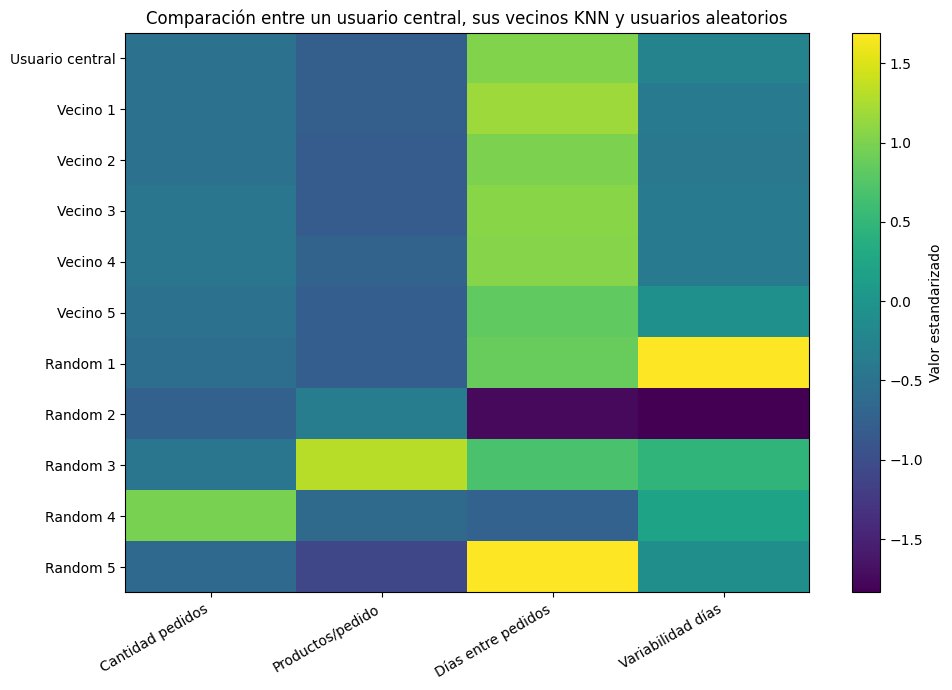

In [ ]:
# ============================================================
# AUDITORÍA VISUAL - VECINOS POR PERFIL DE COMPRA
# ============================================================


rfm_cols = [
    "Cant_de_pedidos",
    "avg_products_per_order_user",
    "avg_days_between_orders",
    "std_days_between_orders",
]


# Una fila por usuario
rfm_profiles = (
    model_table_valid[
        ["user_id"] + rfm_cols
    ]
    .drop_duplicates("user_id")
    .copy()
)


# Estandarizamos solamente para visualizar
rfm_z = rfm_profiles.copy()

rfm_z[rfm_cols] = (
    rfm_z[rfm_cols] - rfm_z[rfm_cols].mean()
) / rfm_z[rfm_cols].std()


# Usuario de ejemplo
sample_user = (
    rfm_neighbors_audit["user_id"]
    .iloc[0]
)


# Top 5 vecinos
neighbor_ids = (
    rfm_neighbors_audit[
        rfm_neighbors_audit["user_id"]
        == sample_user
    ]
    .sort_values("rfm_neighbor_rank")
    .head(5)["neighbor_user_id"]
    .tolist()
)


# 5 usuarios aleatorios para comparar
available_random = rfm_z[
    ~rfm_z["user_id"].isin(
        [sample_user] + neighbor_ids
    )
]

random_ids = (
    available_random
    .sample(5, random_state=42)["user_id"]
    .tolist()
)


users_to_show = (
    [sample_user]
    + neighbor_ids
    + random_ids
)


plot_df = (
    rfm_z[
        rfm_z["user_id"].isin(users_to_show)
    ]
    .set_index("user_id")
    .loc[users_to_show, rfm_cols]
)


labels = (
    ["Usuario central"]
    + [f"Vecino {i}" for i in range(1, 6)]
    + [f"Random {i}" for i in range(1, 6)]
)


fig, ax = plt.subplots(
    figsize=(10, 7)
)

im = ax.imshow(
    plot_df.values,
    aspect="auto"
)

ax.set_xticks(
    range(len(rfm_cols))
)

ax.set_xticklabels(
    [
        "Cantidad pedidos",
        "Productos/pedido",
        "Días entre pedidos",
        "Variabilidad días",
    ],
    rotation=30,
    ha="right"
)

ax.set_yticks(
    range(len(labels))
)

ax.set_yticklabels(
    labels
)

ax.set_title(
    "Comparación entre un usuario central, sus vecinos KNN y usuarios aleatorios",
)

plt.colorbar(
    im,
    ax=ax,
    label="Valor estandarizado"
)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 1. ELEGIR UN USUARIO CON VECINOS MUY SIMILARES
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


N_NEIGHBORS = 5


# ------------------------------------------------------------
# Promedio de similitud de los top 5 vecinos por usuario
# ------------------------------------------------------------

top5_neighbors = (
    product_neighbors_audit
    .sort_values(
        ["user_id", "product_neighbor_rank"]
    )
    .groupby("user_id")
    .head(N_NEIGHBORS)
    .copy()
)


neighbor_quality = (
    top5_neighbors
    .groupby("user_id", as_index=False)
    .agg(
        mean_neighbor_similarity=(
            "product_similarity",
            "mean"
        ),
        min_neighbor_similarity=(
            "product_similarity",
            "min"
        )
    )
)


# ------------------------------------------------------------
# Cantidad de productos históricos distintos por usuario
# ------------------------------------------------------------

user_product_breadth = (
    history_valid_audit
    .groupby("user_id")["product_id"]
    .nunique()
    .rename("unique_products")
    .reset_index()
)


neighbor_quality = (
    neighbor_quality
    .merge(
        user_product_breadth,
        on="user_id",
        how="left"
    )
)


# ------------------------------------------------------------
# Evitamos usuarios demasiado pequeños
#
# El umbral 10 es solamente para elegir
# un caso visualmente interesante.
# ------------------------------------------------------------

good_examples = (
    neighbor_quality[
        neighbor_quality["unique_products"] >= 10
    ]
    .sort_values(
        "mean_neighbor_similarity",
        ascending=False
    )
)


display(
    good_examples.head(10)
)

# ============================================================
# 2. USUARIO CENTRAL + SUS 5 VECINOS
# ============================================================

neighbors = (
    product_neighbors_audit[
        product_neighbors_audit["user_id"]
        == sample_user
    ]
    .sort_values(
        "product_neighbor_rank"
    )
    .head(N_NEIGHBORS)
    .copy()
)

neighbor_ids = (
    neighbors[
        "neighbor_user_id"
    ]
    .tolist()
)

users_to_show = (
    [sample_user]
    + neighbor_ids
)


display(
    neighbors[
        [
            "neighbor_user_id",
            "product_neighbor_rank",
            "product_similarity"
        ]
    ]
)


NameError: name 'history_valid_audit' is not defined

## 11.4 Señales colaborativas


In [ ]:
collaborative_cols = [
    "neighbor_buyers",
    "neighbor_similarity_sum",
    "neighbor_similarity_max",
    "neighbor_similarity_mean",
]

display(
    model_table_valid.groupby("target")[
        collaborative_cols
    ].agg(["mean", "median"])
)


neighbor_buyers        neighbor_similarity_sum         \
                  mean median                    mean median   
target                                                         
0                 1.17   1.00                    0.25   0.16   
1                 2.22   1.00                    0.50   0.27   

       neighbor_similarity_max        neighbor_similarity_mean         
                          mean median                     mean median  
target                                                                 
0                         0.13   0.15                     0.12   0.14  
1                         0.16   0.18                     0.15   0.17

## 11.5 Popularidad global


In [ ]:
popularity_cols = [
    "global_unique_buyers",
    "global_purchase_count",
    "global_product_penetration",
]

display(
    model_table_valid.groupby("target")[
        popularity_cols
    ].agg(["mean", "median"])
)


global_unique_buyers          global_purchase_count            \
                       mean   median                  mean    median   
target                                                                 
0                 10,849.60 5,193.00             38,024.14 13,024.00   
1                  9,830.92 3,045.00             41,125.35  8,850.00   

       global_product_penetration         
                             mean median  
target                                    
0                            0.07   0.03  
1                            0.06   0.02

## 11.6 Market Basket Analysis


In [ ]:
product_pairs_valid = audit_valid_pipeline[
    "product_pairs"
]

reliable_pairs = (
    product_pairs_valid[
        (product_pairs_valid["pair_orders"] >= 20)
        & (product_pairs_valid["orders_a"] >= 100)
        & (product_pairs_valid["orders_b"] >= 100)
    ]
    .sort_values(
        ["lift", "pair_orders"],
        ascending=[False, False]
    )
)

cols_pairs = [
    "product_a",
    "product_name_a",
    "product_b",
    "product_name_b",
    "pair_orders",
    "support",
    "confidence_a_b",
    "confidence_b_a",
    "lift",
]

display(
    reliable_pairs[
        cols_pairs
    ].head(30)
)


,product_a,product_name_a,product_b,product_name_b,pair_orders,support,confidence_a_b,confidence_b_a,lift
166,4519,Chillin' Chicken Recipe,13843,Kickin' Chicken Recipe Dog Food,64,0.00,0.45,0.59,"11,431.57"
178,17332,Flaked Skipjack Tuna Cat Food,24234,Tender Tongol Tuna Cat Food,67,0.00,0.63,0.42,"10,958.47"
185,27678,Savory Shreds with Ocean Whitefish & Tuna in S...,46921,Savory Shreds with Salmon in Sauce Cat Food,54,0.00,0.42,0.50,"10,634.20"
196,11572,Superfood Currant Cacao & Hemp Seedbar,33258,Superfood Organic Gluten Free Mulberry Cacao S...,67,0.00,0.63,0.40,"10,332.87"
223,13843,Kickin' Chicken Recipe Dog Food,32961,Blazin' Beef Recipe Dog Food,55,0.00,0.51,0.38,"9,687.56"
228,29098,Chicken & Salmon Dinner in Gravy Savory Shreds...,46921,Savory Shreds with Salmon in Sauce Cat Food,39,0.00,0.38,0.36,"9,600.32"
230,23437,Chicken Hearts & Liver Feast in Grilled Chicke...,24210,Chicken & Beef Feast in Grilled Chicken Flavor...,60,0.00,0.37,0.57,"9,512.52"
231,41237,Raspberry Coconut Oatmeal Fruit Squeeze,47838,Oatmeal Blueberry Acai Flax Fruit Squeeze,83,0.00,0.61,0.47,"9,498.71"
246,2243,Mango Peach Goat Milk Yogurt Baby Food,4189,"Yogurt, Goat Milk, and Fruit, Banana & Natural...",46,0.00,0.37,0.42,"9,174.85"
251,11572,Superfood Currant Cacao & Hemp Seedbar,15041,"Superfood Cranberry, Almond & Lucuma Seedbar",56,0.00,0.52,0.35,"9,073.72"


In [ ]:
N_orders = N_orders_valid

lift_check = (
    product_pairs_valid
    .head(20)
    .copy()
)

lift_check["prob_a"] = (
    lift_check["orders_a"]
    / N_orders
)

lift_check["prob_b"] = (
    lift_check["orders_b"]
    / N_orders
)

lift_check["prob_ab"] = (
    lift_check["pair_orders"]
    / N_orders
)

lift_check[
    "expected_if_independent"
] = (
    lift_check["prob_a"]
    * lift_check["prob_b"]
)

lift_check["lift_manual"] = (
    lift_check["prob_ab"]
    / lift_check[
        "expected_if_independent"
    ]
)

display(
    lift_check[
        [
            "product_name_a",
            "product_name_b",
            "pair_orders",
            "prob_ab",
            "expected_if_independent",
            "lift",
            "lift_manual",
        ]
    ]
)


,product_name_a,product_name_b,pair_orders,prob_ab,expected_if_independent,lift,lift_manual
0,Moisturizing Non-Drying Facial Wash,Moisturizing Facial Wash,35,0.00,0.00,"78,265.43","78,265.43"
1,2chic Avocado & Olive Oil Conditioner Travel Size,2chic Avocado & Olive Oil Shampoo Travel Size,20,0.00,0.00,"65,221.19","65,221.19"
2,Hi-Chew Fruit Chews Green Apple,Hi-Chew Mango Fruit Chews,27,0.00,0.00,"60,425.51","60,425.51"
3,Red Sugar Sprinkles,Dark Green Sugar Sprinkles,23,0.00,0.00,"59,662.57","59,662.57"
4,Hi-Chew Strawberry Fruit Chews,Hi-Chew Mango Fruit Chews,27,0.00,0.00,"54,064.93","54,064.93"
5,Hi-Chew Fruit Chews Green Apple,Hi-Chew Strawberry Fruit Chews,25,0.00,0.00,"53,004.84","53,004.84"
6,Fruit Punch Super Drink,Tropical Citrus Super Drink,20,0.00,0.00,"43,934.08","43,934.08"
7,Apple Kiwi Strawberry Concentrate Frozen,Apple Cherry Concentrate Frozen,25,0.00,0.00,"40,763.24","40,763.24"
8,Bellavitano Raspberry Wedge,"Cheese, Aged Dutch, Vincent",20,0.00,0.00,"39,021.23","39,021.23"
9,Jewel Signature Provolone,Fully Cooked Boneless Ribs in Sweet Hickory Sauce,22,0.00,0.00,"38,880.25","38,880.25"


## 11.7 Asociación con último carrito y productos core


In [ ]:
association_cols = [
    "max_lift_last_basket",
    "mean_lift_last_basket",
    "max_confidence_last_basket",
    "count_last_basket_products",
    "max_lift_core_products",
    "mean_lift_core_products",
    "sum_weighted_lift_core_products",
    "count_lift_core_products",
]

display(
    model_table_valid.groupby("target")[
        association_cols
    ].agg(["mean", "median"])
)


max_lift_last_basket        mean_lift_last_basket         \
                       mean median                  mean median   
target                                                            
0                      8.82   2.43                  5.36   1.69   
1                     27.67   3.28                 15.78   2.04   

       max_confidence_last_basket        count_last_basket_products         \
                             mean median                       mean median   
target                                                                       
0                            0.04   0.02                       6.02   4.00   
1                            0.06   0.02                       8.13   6.00   

       max_lift_core_products        mean_lift_core_products         \
                         mean median                    mean median   
target                                                                
0                       10.57   2.59                    6.46   1.73   
1                       26.33   3.24                   15.33   2.07   

       sum_weighted_lift_core_products        count_lift_core_products         
                                  mean median                     mean median  
target                                                                         
0                                 9.58   4.29                     5.75   6.00  
1                                25.86   6.90                     6.18   7.00

## 11.8 Recencia y cadencia de recompra


In [ ]:
cadence_cols = [
    "days_since_user_product",
    "avg_days_between_product",
    "std_days_between_product",
    "n_intervals_product",
    "reorder_due_ratio",
]

print("Missing por variable:")
display(
    model_table_valid[
        cadence_cols
    ]
    .isna()
    .mean()
    .sort_values(ascending=False)
    .rename("missing_rate")
    .to_frame()
)

print("\nCadencia según target:")
display(
    model_table_valid.groupby("target")[
        cadence_cols
    ].agg(["mean", "median"])
)


Missing por variable:


,missing_rate
std_days_between_product,0.88
reorder_due_ratio,0.80
avg_days_between_product,0.80
days_since_user_product,0.00
n_intervals_product,0.00



Cadencia según target:


days_since_user_product        avg_days_between_product         \
                          mean median                     mean median   
target                                                                  
0                       571.77 999.00                    43.80  30.00   
1                        97.08   7.00                    30.00  21.86   

       std_days_between_product        n_intervals_product         \
                           mean median                mean median   
target                                                              
0                         26.33  17.62                0.57   0.00   
1                         18.67  12.02                4.05   2.00   

       reorder_due_ratio         
                    mean median  
target                           
0                   4.12   1.12  
1                   0.88   0.00

## 11.11 Deciles y Lift en Validation


In [ ]:
eval_df = pd.DataFrame({
    "target": y_valid,
    "probability": valid_score,
})

eval_df["decile"] = pd.qcut(
    eval_df["probability"],
    q=10,
    labels=False,
    duplicates="drop"
)

eval_df["decile"] = (
    eval_df["decile"].max()
    - eval_df["decile"]
    + 1
)

baseline = (
    eval_df["target"]
    .mean()
)

decile_table = (
    eval_df
    .groupby("decile")
    .agg(
        observations=("target", "size"),
        positives=("target", "sum"),
        positive_rate=("target", "mean"),
        avg_probability=("probability", "mean"),
    )
    .reset_index()
)

decile_table["lift"] = (
    decile_table["positive_rate"]
    / baseline
)

display(
    decile_table
    .sort_values("decile")
)


,decile,observations,positives,positive_rate,avg_probability,lift
0,1,2222331,686551,0.31,0.69,5.98
1,2,2222330,213727,0.10,0.39,1.86
2,3,2222330,102209,0.05,0.23,0.89
3,4,2222331,56439,0.03,0.14,0.49
4,5,2222330,35067,0.02,0.09,0.31
5,6,2222330,23221,0.01,0.06,0.20
6,7,2222331,15222,0.01,0.04,0.13
7,8,2222330,9245,0.00,0.03,0.08
8,9,2222330,4739,0.00,0.01,0.04
9,10,2222331,1602,0.00,0.01,0.01


## 11.12 Precision@K, Recall@K y NDCG@K en Validation


In [ ]:
validation_results = (
    model_table_valid[
        ["user_id", "product_id", "target"]
    ]
    .copy()
)

validation_results[
    "probability"
] = valid_score

validation_results["rank"] = (
    validation_results
    .groupby("user_id")[
        "probability"
    ]
    .rank(
        method="first",
        ascending=False
    )
)

for k in [5, 10, 20]:
    metrics_k = ranking_metrics_at_k(
        validation_results,
        valid_target,
        k=k
    )

print(
    "\nEstas métricas toman en cuenta el total REAL de productos "
    "comprados por usuario, estén o no presentes entre los candidatos. "
    "Por lo tanto, Recall y NDCG se ven afectados por la cobertura de candidatos.\n"
    f"Validation @{k} | "
    f"Precision: {metrics_k['precision']:.4f} | "
    f"Recall_total_productos: {metrics_k['recall']:.4f} | "
    f"NDCG_total_productos: {metrics_k['ndcg']:.4f}"
)



Estas métricas toman en cuenta el total REAL de productos comprados por usuario, estén o no presentes entre los candidatos. Por lo tanto, Recall y NDCG se ven afectados por la cobertura de candidatos.
Validation @20 | Precision: 0.2218 | Recall_total_productos: 0.4872 | NDCG_total_productos: 0.4641


## 11.13 Feature Importance


,feature,importance
20,global_unique_buyers,10386
21,global_purchase_count,9467
4,avg_products_per_order_user,9464
5,avg_days_between_orders,8622
6,std_days_between_orders,7958
29,sum_weighted_lift_core_products,7075
8,days_since_user_product,6211
3,Cant_de_pedidos,6180
28,mean_lift_core_products,5705
27,max_lift_core_products,4944


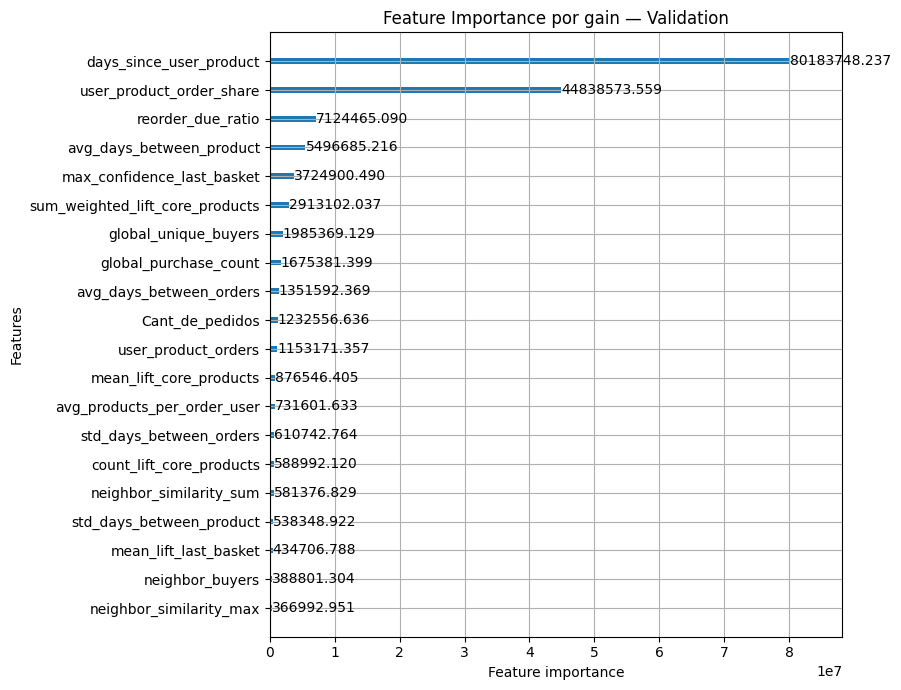

In [ ]:
import lightgbm as lgb

importance = pd.DataFrame({
    "feature": feature_cols,
    "importance": (
        validation_model
        .feature_importances_
    ),
}).sort_values(
    "importance",
    ascending=False
)

display(
    importance.head(20)
)

lgb.plot_importance(
    validation_model,
    max_num_features=20,
    importance_type="gain",
    figsize=(9, 7)
)

plt.title(
    "Feature Importance por gain — Validation"
)
plt.tight_layout()
plt.show()


## 11.14 SHAP global


/Users/Usuario/fer.v1/lib/python3.14/site-packages/shap/explainers/_tree.py:632: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


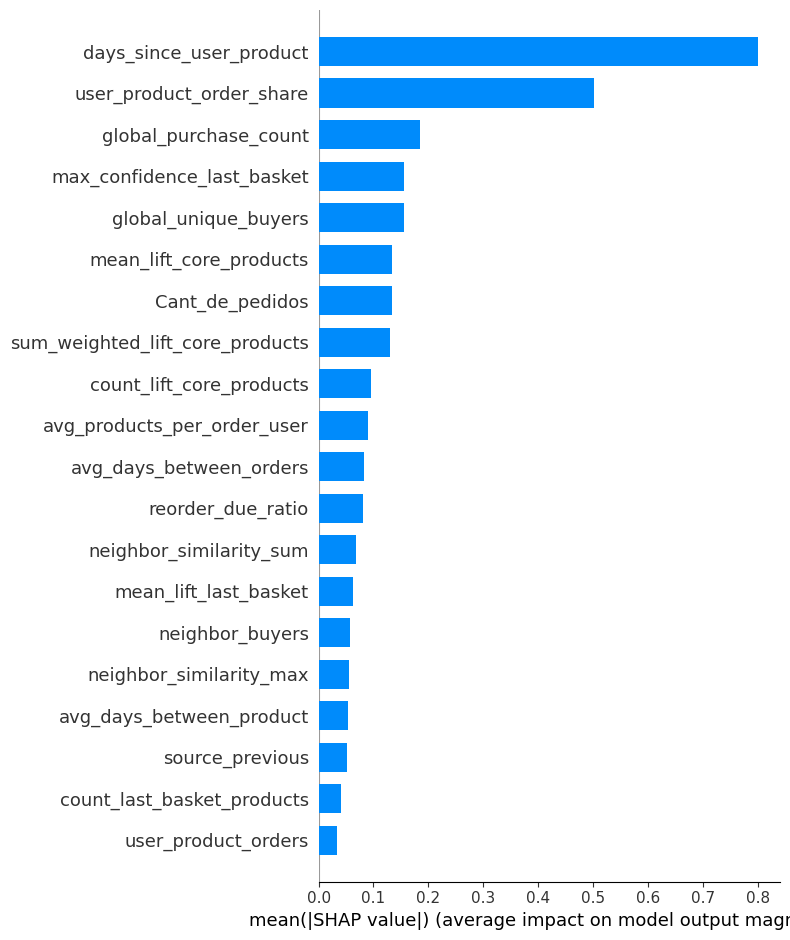

In [ ]:
import shap

explainer = shap.TreeExplainer(
    validation_model
)

X_shap = X_valid.sample(
    n=min(5000, len(X_valid)),
    random_state=42
)

shap_values = explainer.shap_values(
    X_shap
)

if isinstance(
    shap_values,
    list
):
    shap_values = (
        shap_values[1]
    )

shap.summary_plot(
    shap_values,
    X_shap,
    plot_type="bar"
)


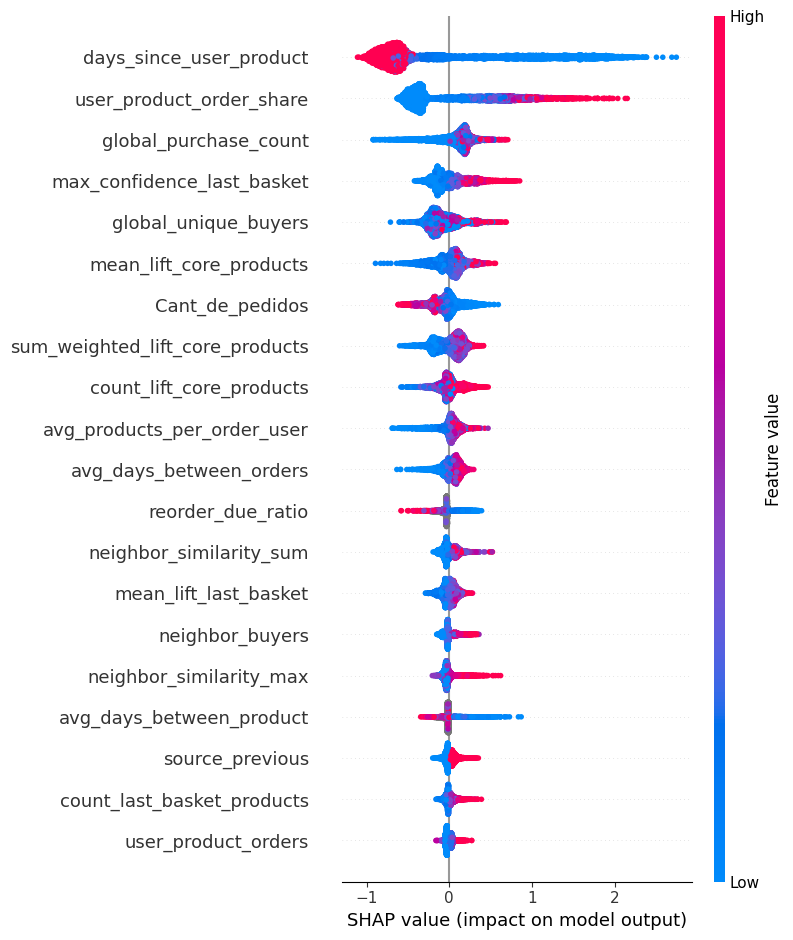

In [ ]:
shap.summary_plot(
    shap_values,
    X_shap
)


In [ ]:
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": (
        np.abs(shap_values)
        .mean(axis=0)
    ),
})

shap_importance = (
    shap_importance
    .sort_values(
        "mean_abs_shap",
        ascending=False
    )
)

shap_importance[
    "importance_pct"
] = (
    shap_importance[
        "mean_abs_shap"
    ]
    / shap_importance[
        "mean_abs_shap"
    ].sum()
)

shap_importance[
    "cumulative_importance"
] = (
    shap_importance[
        "importance_pct"
    ]
    .cumsum()
)

features_90 = shap_importance[
    shap_importance[
        "cumulative_importance"
    ] <= 0.90
]

display(features_90)


,feature,mean_abs_shap,importance_pct,cumulative_importance
8,days_since_user_product,0.80,0.26,0.26
9,user_product_order_share,0.50,0.16,0.42
21,global_purchase_count,0.18,0.06,0.48
25,max_confidence_last_basket,0.16,0.05,0.53
20,global_unique_buyers,0.16,0.05,0.58
28,mean_lift_core_products,0.13,0.04,0.62
3,Cant_de_pedidos,0.13,0.04,0.66
29,sum_weighted_lift_core_products,0.13,0.04,0.70
30,count_lift_core_products,0.10,0.03,0.73
4,avg_products_per_order_user,0.09,0.03,0.76


# 12. Test final

A partir de este punto no se modifica el modelo ni se toman nuevas decisiones.

Primero se liberan los objetos grandes de Train/Validation. Después se construye `history_test` y su `model_table` una única vez.


## 12.1 Liberar memoria antes de construir Test


In [ ]:
# ============================================================
# PREPARAR AUDITORÍA COMPACTA PARA STREAMLIT ANTES DE LIBERAR VALIDATION
# ============================================================
# Guardamos solamente un extracto robusto de pares y un resumen de las
# features de asociación. Son objetos pequeños y luego se exportan al final.

streamlit_mba_pairs = (
    reliable_pairs[cols_pairs]
    .head(5000)
    .copy()
)

streamlit_mba_feature_effectiveness = (
    model_table_valid
    .groupby("target")[association_cols]
    .agg(["mean", "median"])
)

streamlit_mba_feature_effectiveness.columns = [
    f"{feature}__{stat}"
    for feature, stat in streamlit_mba_feature_effectiveness.columns
]

streamlit_mba_feature_effectiveness = (
    streamlit_mba_feature_effectiveness
    .reset_index()
)

print("Objetos compactos de Market Basket preservados para Streamlit.")

# ============================================================
# LIBERAR TRAIN / VALIDATION ANTES DE TEST
# ============================================================

import gc

# Conservamos únicamente el modelo ya seleccionado
best_model = validation_model


for variable in [

    # Modelado
    "model_table_valid",
    "X_train",
    "y_train",
    "X_valid",
    "y_valid",
    "valid_user_ids",
    "valid_score",

    # Objetos históricos
    "model_table_train",
    "history_train",
    "history_valid",
    "train_target",
    "valid_target",

    # Auditorías
    "audit_valid_pipeline",
    "rfm_neighbors_audit",
    "product_neighbors_audit",
    "product_pairs_valid",
    "reliable_pairs",
    "lift_check",
    "coverage_valid",
    "coverage_valid_user",
    "validation_results",
    "eval_df",

    # SHAP
    "X_shap",
    "shap_values",
    "explainer",

]:
    globals().pop(
        variable,
        None
    )


gc.collect()

print(
    "Memoria de Train/Validation liberada. "
    "Listo para construir Test."
)

Objetos compactos de Market Basket preservados para Streamlit.
Memoria de Train/Validation liberada. Listo para construir Test.


## 12.2 Construcción tardía del snapshot de Test

`history_test` contiene información hasta `n-1`. El target es el pedido `n`.


In [ ]:
history_test = data[
    (data["user_id"].isin(eligible_users))
    & (
        data["order_number"]
        <= data["max_order_number"] - 1
    )
]

print(
    "Filas history_test:",
    len(history_test)
)

model_table_test = build_model_table(
    history_test
)

print(
    "Test:",
    model_table_test.shape
)

model_table_test = add_target(
    model_table_test,
    test
)

print(
    "Prevalencia Test:",
    model_table_test["target"].mean()
)


Filas history_test: 29276003
       avg_days_between_orders  std_days_between_orders  \
count               162,633.00               162,633.00   
mean                     14.22                     6.83   
std                       6.59                     2.91   
min                       0.00                     0.00   
25%                       8.88                     4.69   
50%                      13.39                     7.14   
75%                      18.84                     8.99   
max                      30.00                    17.32   

       avg_products_per_order_user  Cant_de_pedidos  
count                   162,633.00       162,633.00  
mean                         10.01            17.84  
std                           5.80            17.37  
min                           1.00             4.00  
25%                           5.86             6.00  
50%                           9.00            11.00  
75%                          13.00            22.00  
max    

## 12.3 Cobertura de candidatos en Test


In [ ]:
coverage_test, coverage_test_user = candidate_coverage(
    model_table_test,
    test
)

print(
    "Cobertura global Test:",
    coverage_test["in_candidates"].mean()
)

print(
    "Cobertura promedio por usuario Test:",
    coverage_test_user["candidate_recall"].mean()
)


Cobertura global Test: 0.6845202837801397
Cobertura promedio por usuario Test: 0.6901108746935641


## 12.4 Predicción sobre Test

Se crean únicamente las columnas necesarias para predecir y reportar resultados. Después se eliminan `model_table_test` e `history_test` antes de calcular las métricas de ranking.


In [ ]:
# ============================================================
# 12.4 PREDICCIÓN SOBRE TEST + BASE COMPACTA PARA STREAMLIT
# ============================================================

# Identificadores compactos para evaluación.
test_results = (
    model_table_test[
        ["user_id", "product_id", "target"]
    ]
    .copy()
)

# Matriz del modelo. Mantiene el mismo índice que test_results,
# lo que nos permite recuperar después únicamente las features del Top 20.
X_test = (
    model_table_test[feature_cols]
    .replace([np.inf, -np.inf], np.nan)
)

# model_table_test ya no es necesario: X_test conserva las features.
del model_table_test
del history_test
gc.collect()

# Score de propensión.
test_proba = best_model.predict_proba(
    X_test
)[:, 1]

test_ap = average_precision_score(
    test_results["target"],
    test_proba
)

test_results["probability"] = test_proba

test_results["rank"] = (
    test_results
    .groupby("user_id")["probability"]
    .rank(method="first", ascending=False)
)

# ------------------------------------------------------------
# BASE COMPACTA TOP 20 PARA STREAMLIT
# ------------------------------------------------------------
# Guardamos solamente los 20 productos mejor rankeados por usuario
# y las features que necesitamos para explicar la propensión.

streamlit_explain_cols = [
    # Fuentes de candidato
    "source_previous",
    "source_similar_users",
    "source_global_popular",

    # Perfil cliente
    "Cant_de_pedidos",
    "avg_products_per_order_user",
    "avg_days_between_orders",
    "std_days_between_orders",

    # Histórico cliente-producto / cadencia
    "user_product_orders",
    "user_product_order_share",
    "days_since_user_product",
    "avg_days_between_product",
    "std_days_between_product",
    "n_intervals_product",
    "reorder_due_ratio",

    # Colaborativo
    "neighbor_buyers",
    "neighbor_similarity_sum",
    "neighbor_similarity_max",
    "neighbor_similarity_mean",

    # Popularidad
    "global_unique_buyers",
    "global_purchase_count",
    "global_product_penetration",

    # Market Basket Analysis
    "max_lift_last_basket",
    "mean_lift_last_basket",
    "max_confidence_last_basket",
    "count_last_basket_products",
    "max_lift_core_products",
    "mean_lift_core_products",
    "sum_weighted_lift_core_products",
    "count_lift_core_products",
]

streamlit_top20_mask = (
    test_results["rank"] <= 20
)

streamlit_top20 = (
    test_results.loc[
        streamlit_top20_mask,
        ["user_id", "product_id", "target", "probability", "rank"]
    ]
    .copy()
)

# Las filas conservan el mismo índice que X_test.
streamlit_top20 = pd.concat(
    [
        streamlit_top20,
        X_test.loc[
            streamlit_top20_mask,
            streamlit_explain_cols
        ].copy()
    ],
    axis=1
)

streamlit_top20 = (
    streamlit_top20
    .rename(columns={"probability": "propensity_score"})
    .reset_index(drop=True)
)

streamlit_top20["rank"] = (
    streamlit_top20["rank"]
    .astype("int16")
)

# Bandas comerciales definidas para la app.
streamlit_top20["propensity_band"] = np.select(
    [
        streamlit_top20["propensity_score"] >= 0.60,
        streamlit_top20["propensity_score"] >= 0.25,
    ],
    [
        "Alta",
        "Media",
    ],
    default="Baja"
)

# ------------------------------------------------------------
# SHAP LOCAL PARA LA APP (CLIENTE-PRODUCTO)
# ------------------------------------------------------------
# Se calcula offline y se escribe por bloques: Streamlit solamente lee
# la fila correspondiente a la combinación seleccionada.
from pathlib import Path
import sys

shap_project_dir = Path("Instacart Recommender")
if not (shap_project_dir / "src").exists():
    shap_project_dir = Path(".")
if str(shap_project_dir.resolve()) not in sys.path:
    sys.path.insert(0, str(shap_project_dir.resolve()))

from src.shap_export import export_local_shap

export_local_shap(
    model=best_model,
    features=X_test.loc[streamlit_top20_mask, feature_cols],
    identifiers=(
        test_results.loc[streamlit_top20_mask, ["user_id", "product_id"]]
        .reset_index(drop=True)
    ),
    output_path=shap_project_dir / "data" / "local_shap_top20.parquet",
)
print("SHAP local exportado para la app.")

# Liberamos los objetos gigantes recién después de capturar el Top 20.
del X_test
del test_proba
del streamlit_top20_mask
gc.collect()

print(
    f"Average Precision Test final: {test_ap:.4f}"
)
print(
    "Top 20 preparado para Streamlit:",
    streamlit_top20.shape
)


Average Precision Test final: 0.3935
Top 20 preparado para Streamlit: (3252660, 35)


## 12.5 Precision@K, Recall@K y NDCG@K — Test final


In [ ]:
test_metrics = {}

for k in [5, 10, 20]:
    metrics_k = ranking_metrics_at_k(
        test_results,
        test,
        k=k
    )

    test_metrics[k] = metrics_k

    print(
        f"Test @{k} | "
        f"Precision: "
        f"{metrics_k['precision']:.4f} | "
        f"Recall: "
        f"{metrics_k['recall']:.4f} | "
        f"NDCG: "
        f"{metrics_k['ndcg']:.4f}"
    )


Test @5 | Precision: 0.4008 | Recall: 0.2588 | NDCG: 0.4662
Test @10 | Precision: 0.3132 | Recall: 0.3689 | NDCG: 0.4465
Test @20 | Precision: 0.2238 | Recall: 0.4850 | NDCG: 0.4625


## 12.6 Resumen final

Estos son los resultados finales sobre el último pedido (`n`). No deben utilizarse para volver a ajustar hiperparámetros, features o threshold.


In [ ]:
print(
    "================ RESULTADO FINAL ================"
)

print(
    f"Average Precision Test: "
    f"{test_ap:.4f}"
)

print(
    "Cobertura promedio de candidatos: "
    f"{coverage_test_user['candidate_recall'].mean():.4f}"
)

for k in [5, 10, 20]:
    metrics_k = test_metrics[k]

    print(
        f"@{k} | "
        f"Precision: "
        f"{metrics_k['precision']:.4f} | "
        f"Recall: "
        f"{metrics_k['recall']:.4f} | "
        f"NDCG: "
        f"{metrics_k['ndcg']:.4f}"
    )


================ RESULTADO FINAL ================
Average Precision Test: 0.3935
Cobertura promedio de candidatos: 0.6901
@5 | Precision: 0.4008 | Recall: 0.2588 | NDCG: 0.4662
@10 | Precision: 0.3132 | Recall: 0.3689 | NDCG: 0.4465
@20 | Precision: 0.2238 | Recall: 0.4850 | NDCG: 0.4625


## Mejoras

í. Yo dejaría anotados estos puntos de mejora del recomendador, en este orden de prioridad:

Mejorar la generación de candidatos. Actualmente la cobertura es 72,4%, por lo que aproximadamente el 27,6% de los productos realmente comprados nunca llegan a LightGBM. Analizar qué productos quedan afuera y agregar nuevas fuentes de candidatos podría aumentar bastante el techo de Recall.
Comparar contra baselines. Medir Precision@10, Recall@10 y NDCG@10 contra métodos simples: productos más frecuentes del usuario, productos globalmente populares y eventualmente random. Esto permite demostrar cuánto valor agrega realmente LightGBM.
Optimizar mejor los hiperparámetros con Optuna. Por ahora prácticamente vimos un trial. Una vez estabilizado el pipeline, correr 20–30 trials y comparar AP y métricas de ranking.
Evaluar si optimizar AP es lo más conveniente. Actualmente Optuna maximiza Average Precision. Comparar si los parámetros que maximizan AP también maximizan NDCG@10 o Recall@10, que están más directamente relacionados con el objetivo del recomendador.
Analizar/calibrar las probabilidades. Debido especialmente a scale_pos_weight, predict_proba() funciona muy bien como score de propensión, pero no necesariamente significa probabilidad real. Crear calibration curve y, si necesitás probabilidades interpretables, probar sigmoid/Platt o isotonic calibration.
Revisar scale_pos_weight. Optuna actualmente lo ajusta para manejar el desbalance. Analizar qué efecto tiene sobre ranking, Recall y calibración. No usaría SMOTE de entrada.
Investigar los falsos positivos y falsos negativos. Comparar variables como user_product_orders, days_since_user_product, reorder_due_ratio, señales de vecinos y lift para descubrir patrones sistemáticos de error.
Analizar las fuentes de candidatos y sus combinaciones. Ya vimos tasas aproximadas de positivos de 9% para histórico, 6% para vecinos y 3% para popularidad. Evaluar especialmente si combinaciones como previous + similar tienen una tasa de compra mucho mayor.
Revisar Market Basket y asociaciones extremas. Algunos lifts son enormes debido a productos muy raros. Conviene exigir suficiente support, pair_orders y frecuencia individual para evitar asociaciones poco robustas.
Optimizar consumo de memoria y tiempo. Mantener Train/Validation solamente durante desarrollo, liberar objetos grandes antes de construir Test y evitar transformaciones costosas sobre los ~17 millones de candidatos.
Eventualmente implementar validación temporal con varios snapshots. En vez de una sola ventana Train→Validation, usar varios puntos temporales antes del Test final para comprobar que el rendimiento sea estable a través del tiempo.
Mantener separadas métricas de clasificación y recomendación. AP para discriminación global; Precision@K, Recall@K y NDCG@K para evaluar el producto final. El threshold/F1 sirve como auditoría, pero no es central si la salida real es un Top-K.

De todos estos, yo atacaría primero candidate coverage + baselines, antes de dedicar mucho tiempo a exprimir unas centésimas adicionales de AP con LightGBM.


Re agregar los graficos de cercanía entre vecinos. 3d
Y ver si falta algun grafico mas.


Importante agregar chequeos confiables en cada paso del pipeline. Para ver que todas las variables esten sumando valor. 

Siguientes pasos: 

Estudiar todo tranquilo 3 dias. Entende todo y pone palabras intuitivas sin apuro. 

In [ ]:
# ============================================================
# BASELINE TEST: PRODUCTOS MÁS POPULARES
# ============================================================

import numpy as np
import pandas as pd


# ------------------------------------------------------------
# 1. CONSTRUIR TARGET DE TEST
# ------------------------------------------------------------

# Pedido n de cada usuario.
# Usamos únicamente user_id-product_id porque eso es
# lo que necesitamos para evaluar las recomendaciones.

test_target_baseline = (
    data[
        (
            data["user_id"].isin(eligible_users)
        )
        &
        (
            data["order_number"]
            == data["max_order_number"]
        )
    ][
        [
            "user_id",
            "product_id"
        ]
    ]
    .drop_duplicates()
    .copy()
)

print(
    "Test target:",
    test_target_baseline.shape
)


# ------------------------------------------------------------
# 2. CALCULAR POPULARIDAD USANDO SOLO HISTORY TEST
# ------------------------------------------------------------

# Para predecir el pedido n podemos utilizar solamente
# la información disponible hasta n-1.

history_test_popularity = (
    data[
        (
            data["user_id"].isin(eligible_users)
        )
        &
        (
            data["order_number"]
            <= data["max_order_number"] - 1
        )
    ][
        [
            "user_id",
            "product_id",
            "order_id"
        ]
    ]
)


# ------------------------------------------------------------
# 3. POPULARIDAD GLOBAL DE PRODUCTOS
# ------------------------------------------------------------

global_popularity_test = (
    history_test_popularity
    .groupby(
        "product_id",
        as_index=False
    )
    .agg(

        unique_buyers=(
            "user_id",
            "nunique"
        ),

        purchase_count=(
            "order_id",
            "nunique"
        )
    )
    .sort_values(
        [
            "unique_buyers",
            "purchase_count"
        ],
        ascending=[
            False,
            False
        ]
    )
)

print(
    "Productos disponibles:",
    len(global_popularity_test)
)


# Ya no necesitamos el historial temporal completo
del history_test_popularity


# ------------------------------------------------------------
# 4. PRODUCTOS REALES DEL PEDIDO TEST POR USUARIO
# ------------------------------------------------------------

actual_by_user_test = (
    test_target_baseline
    .groupby("user_id")["product_id"]
    .apply(set)
)


# ------------------------------------------------------------
# 5. FUNCIÓN PARA CALCULAR MÉTRICAS @K
# ------------------------------------------------------------

def evaluate_popularity_at_k(
    popularity_table,
    actual_by_user,
    k
):

    # Los mismos Top-K productos populares
    # se recomiendan a todos los usuarios.

    recommended_products = (
        popularity_table
        .head(k)["product_id"]
        .tolist()
    )

    recommended_set = set(
        recommended_products
    )

    precisions = []
    recalls = []
    ndcgs = []


    for user_id, actual_products in actual_by_user.items():

        # ----------------------------------------------------
        # HITS
        # ----------------------------------------------------

        hits = (
            recommended_set
            &
            actual_products
        )

        n_hits = len(hits)


        # ----------------------------------------------------
        # PRECISION@K
        # ----------------------------------------------------

        precision = (
            n_hits / k
        )

        precisions.append(
            precision
        )


        # ----------------------------------------------------
        # RECALL@K
        # ----------------------------------------------------

        recall = (
            n_hits
            /
            len(actual_products)
        )

        recalls.append(
            recall
        )


        # ----------------------------------------------------
        # NDCG@K
        # ----------------------------------------------------

        relevance = np.array(
            [
                1
                if product_id in actual_products
                else 0

                for product_id
                in recommended_products
            ]
        )


        discounts = (
            1
            /
            np.log2(
                np.arange(
                    2,
                    k + 2
                )
            )
        )


        dcg = (
            relevance
            *
            discounts
        ).sum()


        # Ranking ideal:
        # todos los productos relevantes primero.

        ideal_hits = min(
            len(actual_products),
            k
        )

        ideal_relevance = np.zeros(
            k
        )

        ideal_relevance[
            :ideal_hits
        ] = 1


        idcg = (
            ideal_relevance
            *
            discounts
        ).sum()


        ndcg = (
            dcg / idcg
            if idcg > 0
            else 0
        )

        ndcgs.append(
            ndcg
        )


    return {

        "K": k,

        "Precision@K":
            np.mean(precisions),

        "Recall@K":
            np.mean(recalls),

        "NDCG@K":
            np.mean(ndcgs)
    }


# ------------------------------------------------------------
# 6. EVALUAR K = 5, 10 Y 20
# ------------------------------------------------------------

popularity_test_results = pd.DataFrame(
    [
        evaluate_popularity_at_k(
            global_popularity_test,
            actual_by_user_test,
            k
        )

        for k in [
            5,
            10,
            20
        ]
    ]
)


# ------------------------------------------------------------
# 7. RESULTADOS
# ------------------------------------------------------------

print("\n======================================")
print("BASELINE POPULARIDAD - TEST")
print("======================================\n")

display(
    popularity_test_results.round(4)
)


# ============================================================
# BASELINE TEST: PRODUCTOS HISTÓRICOS DEL CLIENTE
# ============================================================
# Recomienda los productos comprados anteriormente, ordenados por
# frecuencia y, ante empate, por compra más reciente. Sólo usa n-1.

previous_products_test = (
    data.loc[
        data["user_id"].isin(eligible_users)
        & (data["order_number"] <= data["max_order_number"] - 1),
        ["user_id", "product_id", "order_id", "order_number"],
    ]
    .groupby(["user_id", "product_id"], as_index=False)
    .agg(
        historical_orders=("order_id", "nunique"),
        last_order_number=("order_number", "max"),
    )
    .sort_values(
        ["user_id", "historical_orders", "last_order_number", "product_id"],
        ascending=[True, False, False, True],
    )
)

previous_by_user_test = (
    previous_products_test.groupby("user_id")["product_id"].apply(list)
)

def evaluate_previous_products_at_k(previous_by_user, actual_by_user, k):
    precisions, recalls, ndcgs = [], [], []
    discounts = 1 / np.log2(np.arange(2, k + 2))

    for user_id, actual_products in actual_by_user.items():
        recommended = list(previous_by_user.get(user_id, []))[:k]
        relevance = np.zeros(k, dtype="int8")
        if recommended:
            relevance[:len(recommended)] = [
                int(product_id in actual_products) for product_id in recommended
            ]
        hits = int(relevance.sum())
        precisions.append(hits / k)
        recalls.append(hits / len(actual_products))
        dcg = float((relevance * discounts).sum())
        ideal_hits = min(len(actual_products), k)
        idcg = float(discounts[:ideal_hits].sum())
        ndcgs.append(dcg / idcg if idcg > 0 else 0.0)

    return {
        "K": k,
        "Precision@K": np.mean(precisions),
        "Recall@K": np.mean(recalls),
        "NDCG@K": np.mean(ndcgs),
    }

previous_test_results = pd.DataFrame([
    evaluate_previous_products_at_k(previous_by_user_test, actual_by_user_test, k)
    for k in [5, 10, 20]
])

print("\n======================================")
print("BASELINE PRODUCTOS HISTÓRICOS - TEST")
print("======================================\n")
display(previous_test_results.round(4))

Test target: (1716963, 2)
Productos disponibles: 49616

BASELINE POPULARIDAD - TEST



,K,Precision@K,Recall@K,NDCG@K
0,5,0.10,0.05,0.11
1,10,0.07,0.07,0.10
2,20,0.05,0.10,0.10


# ============================================
## 13. EXPORTS PARA STREAMLIT
# ============================================

In [ ]:
# ============================================================
# 13. EXPORTS PARA STREAMLIT
# ============================================================
# Esta celda crea únicamente tablas compactas para serving.
# Streamlit NO recalcula candidatos, vecinos, Market Basket ni LightGBM.

from pathlib import Path
import json
import duckdb
import numpy as np
import pandas as pd

STREAMLIT_PROJECT_DIR = Path("Instacart Recommender")
STREAMLIT_DATA_DIR = STREAMLIT_PROJECT_DIR / "data"
STREAMLIT_DATA_DIR.mkdir(parents=True, exist_ok=True)

print("Exportando a:", STREAMLIT_DATA_DIR.resolve())


# ------------------------------------------------------------
# 1. RESUMEN GENERAL DEL DATASET INSTACART
# ------------------------------------------------------------
# Usamos las tablas originales de DuckDB para que los KPIs representen
# el dataset completo y no solamente el snapshot de modelado.

with duckdb.connect(DB_PATH) as con:
    dataset_summary = con.execute("""
        SELECT
            (SELECT COUNT(DISTINCT user_id) FROM orders) AS clients,
            (SELECT COUNT(*) FROM orders) AS orders,
            (SELECT COUNT(*) FROM products) AS products,
            (SELECT COUNT(*) FROM departments) AS departments,
            (SELECT COUNT(*) FROM aisles) AS aisles,
            (
                (SELECT COUNT(*) FROM order_products__prior)
                +
                (SELECT COUNT(*) FROM order_products__train)
            ) AS order_product_lines
    """).fetchdf()

    orders_per_user = con.execute("""
        SELECT
            user_id,
            COUNT(*) AS n_orders
        FROM orders
        GROUP BY user_id
    """).fetchdf()


dataset_summary.to_parquet(
    STREAMLIT_DATA_DIR / "dataset_summary.parquet",
    index=False
)

orders_per_user.to_parquet(
    STREAMLIT_DATA_DIR / "orders_per_user.parquet",
    index=False
)


# ------------------------------------------------------------
# 2. CATÁLOGO DE PRODUCTOS
# ------------------------------------------------------------

product_catalog = (
    data[
        ["product_id", "product_name", "department"]
    ]
    .drop_duplicates("product_id")
    .sort_values("product_id")
    .reset_index(drop=True)
)

product_catalog.to_parquet(
    STREAMLIT_DATA_DIR / "product_catalog.parquet",
    index=False
)


# ------------------------------------------------------------
# 3. TOP 20 DE PROPENSIÓN POR CLIENTE
# ------------------------------------------------------------
# target se conserva en memoria para auditoría, pero NO se exporta a la app:
# en producción el próximo carrito todavía no es conocido.

recommendation_export_cols = [
    "user_id",
    "product_id",
    "rank",
    "propensity_score",
    "propensity_band",
] + streamlit_explain_cols

recommendations_top20 = (
    streamlit_top20[recommendation_export_cols]
    .copy()
)

# Reducimos tipos donde es seguro para achicar el Parquet.
for col in recommendations_top20.select_dtypes(include=["float64"]).columns:
    recommendations_top20[col] = recommendations_top20[col].astype("float32")

recommendations_top20.to_parquet(
    STREAMLIT_DATA_DIR / "recommendations_top20.parquet",
    index=False,
    compression="snappy"
)


# ------------------------------------------------------------
# 4. PERFIL EJECUTIVO DE CADA CLIENTE
# ------------------------------------------------------------

customer_profiles = (
    recommendations_top20[
        [
            "user_id",
            "Cant_de_pedidos",
            "avg_products_per_order_user",
            "avg_days_between_orders",
            "std_days_between_orders",
        ]
    ]
    .drop_duplicates("user_id")
    .rename(
        columns={
            "Cant_de_pedidos": "historical_orders",
            "avg_products_per_order_user": "avg_products_per_order",
        }
    )
)

# El target de Test es el pedido n; por eso el último pedido histórico
# disponible para scoring es n-1.
last_order_number = (
    test[
        ["user_id", "max_order_number"]
    ]
    .drop_duplicates("user_id")
    .assign(
        last_historical_order_number=lambda x: x["max_order_number"] - 1
    )[
        ["user_id", "last_historical_order_number"]
    ]
)

customer_profiles = customer_profiles.merge(
    last_order_number,
    on="user_id",
    how="left",
    validate="one_to_one"
)

customer_profiles.to_parquet(
    STREAMLIT_DATA_DIR / "customer_profiles.parquet",
    index=False
)


# ------------------------------------------------------------
# 5. MARKET BASKET ANALYSIS: PARES ROBUSTOS
# ------------------------------------------------------------

streamlit_mba_pairs.to_parquet(
    STREAMLIT_DATA_DIR / "mba_pairs.parquet",
    index=False
)


# ------------------------------------------------------------
# 6. MARKET BASKET: CAPACIDAD DISCRIMINANTE DE LAS FEATURES
# ------------------------------------------------------------
# Convertimos el resumen target=0/1 a formato largo para graficarlo fácil.

mba_rows = []

for _, row in streamlit_mba_feature_effectiveness.iterrows():
    target_value = int(row["target"])

    for feature in association_cols:
        mba_rows.append({
            "target": target_value,
            "feature": feature,
            "mean": row[f"{feature}__mean"],
            "median": row[f"{feature}__median"],
        })

mba_feature_effectiveness = pd.DataFrame(mba_rows)

mba_feature_effectiveness.to_parquet(
    STREAMLIT_DATA_DIR / "mba_feature_effectiveness.parquet",
    index=False
)


# ------------------------------------------------------------
# 7. MÉTRICAS PRINCIPALES: NDCG, RECALL Y PRECISION
# ------------------------------------------------------------
# Para la app hacemos foco en ranking. Se incluye el baseline de popularidad.

model_metric_rows = []

for k in [5, 10, 20]:
    model_k = test_metrics[k]

    baseline_k = (
        popularity_test_results
        .loc[popularity_test_results["K"] == k]
        .iloc[0]
    )

    previous_baseline_k = (
        previous_test_results
        .loc[previous_test_results["K"] == k]
        .iloc[0]
    )

    model_metric_rows.append({
        "k": k,
        "precision": model_k["precision"],
        "recall": model_k["recall"],
        "ndcg": model_k["ndcg"],
        "baseline_precision": baseline_k["Precision@K"],
        "baseline_recall": baseline_k["Recall@K"],
        "baseline_ndcg": baseline_k["NDCG@K"],
        "previous_baseline_precision": previous_baseline_k["Precision@K"],
        "previous_baseline_recall": previous_baseline_k["Recall@K"],
        "previous_baseline_ndcg": previous_baseline_k["NDCG@K"],
    })

model_metrics = pd.DataFrame(model_metric_rows)

model_metrics.to_parquet(
    STREAMLIT_DATA_DIR / "model_metrics.parquet",
    index=False
)


# ------------------------------------------------------------
# 7.1 PODER DE DISCRIMINACIÓN POR DECILES (VALIDATION)
# ------------------------------------------------------------
# El decil 1 contiene los pares cliente-producto con mayor score.

model_deciles = decile_table.sort_values("decile").copy()
model_deciles["evaluation_split"] = "Validation"
model_deciles.to_parquet(
    STREAMLIT_DATA_DIR / "model_deciles.parquet",
    index=False
)


# ------------------------------------------------------------
# 8. CATÁLOGO DE FEATURES PARA LA SECCIÓN "CÓMO SE PREDICE"
# ------------------------------------------------------------

feature_catalog = pd.DataFrame([
    # Fuentes
    ("Fuentes de candidatos", "source_previous", "El producto ya fue comprado por el cliente."),
    ("Fuentes de candidatos", "source_similar_users", "El producto aparece en clientes con comportamiento de compra similar."),
    ("Fuentes de candidatos", "source_global_popular", "El producto entra por popularidad global."),

    # Cliente
    ("Perfil del cliente", "Cant_de_pedidos", "Cantidad de pedidos históricos disponibles."),
    ("Perfil del cliente", "avg_products_per_order_user", "Tamaño promedio del carrito del cliente."),
    ("Perfil del cliente", "avg_days_between_orders", "Frecuencia promedio entre pedidos."),
    ("Perfil del cliente", "std_days_between_orders", "Variabilidad de la frecuencia de compra."),

    # Histórico producto
    ("Histórico cliente-producto", "user_product_orders", "Cantidad de pedidos donde el cliente compró el producto."),
    ("Histórico cliente-producto", "user_product_order_share", "Proporción de pedidos del cliente que contienen el producto."),
    ("Histórico cliente-producto", "days_since_user_product", "Días transcurridos desde la última compra del producto."),
    ("Histórico cliente-producto", "avg_days_between_product", "Cadencia promedio de recompra del producto."),
    ("Histórico cliente-producto", "reorder_due_ratio", "Compara la recencia actual con la cadencia histórica de recompra."),

    # Colaborativo
    ("Filtrado colaborativo", "neighbor_buyers", "Cantidad de vecinos similares que compraron el producto."),
    ("Filtrado colaborativo", "neighbor_similarity_sum", "Suma de similitud de los vecinos compradores."),
    ("Filtrado colaborativo", "neighbor_similarity_max", "Mayor similitud observada entre vecinos compradores."),
    ("Filtrado colaborativo", "neighbor_similarity_mean", "Similitud promedio de los vecinos compradores."),

    # Popularidad
    ("Popularidad", "global_unique_buyers", "Cantidad de compradores únicos del producto."),
    ("Popularidad", "global_purchase_count", "Cantidad de pedidos históricos que incluyeron el producto."),
    ("Popularidad", "global_product_penetration", "Penetración del producto sobre la base de clientes."),

    # MBA
    ("Market Basket Analysis", "max_lift_last_basket", "Mayor lift entre el candidato y productos del último carrito."),
    ("Market Basket Analysis", "mean_lift_last_basket", "Lift promedio frente a productos del último carrito."),
    ("Market Basket Analysis", "max_confidence_last_basket", "Mayor confidence de asociación con el último carrito."),
    ("Market Basket Analysis", "count_last_basket_products", "Cantidad de productos del último carrito asociados al candidato."),
    ("Market Basket Analysis", "max_lift_core_products", "Mayor lift frente a productos característicos del cliente."),
    ("Market Basket Analysis", "mean_lift_core_products", "Lift promedio frente a productos característicos del cliente."),
    ("Market Basket Analysis", "sum_weighted_lift_core_products", "Suma de lift ponderada por relevancia histórica de los productos core."),
    ("Market Basket Analysis", "count_lift_core_products", "Cantidad de productos core asociados al candidato."),
], columns=["category", "feature", "business_description"])

feature_catalog.to_parquet(
    STREAMLIT_DATA_DIR / "feature_catalog.parquet",
    index=False
)


# ------------------------------------------------------------
# 9. MANIFEST / CONTROL FINAL
# ------------------------------------------------------------

export_manifest = {
    "recommendation_k": 20,
    "high_propensity_threshold": 0.60,
    "medium_propensity_threshold": 0.25,
    "model": "LightGBMClassifier",
    "selection_metric": "NDCG@10",
    "test_metrics": {
        str(k): {
            "precision": float(test_metrics[k]["precision"]),
            "recall": float(test_metrics[k]["recall"]),
            "ndcg": float(test_metrics[k]["ndcg"]),
        }
        for k in [5, 10, 20]
    },
}

with open(
    STREAMLIT_DATA_DIR / "manifest.json",
    "w",
    encoding="utf-8"
) as f:
    json.dump(export_manifest, f, indent=2)


print("\n================ EXPORT STREAMLIT OK ================")
for path in sorted(STREAMLIT_DATA_DIR.glob("*")):
    if path.is_file():
        print(f"{path.name:40s} {path.stat().st_size / 1024**2:8.2f} MB")

print("\nMétricas de ranking exportadas:")
display(model_metrics.round(4))

print("\nMarket Basket - ejemplo de pares robustos:")
display(
    streamlit_mba_pairs[
        [
            "product_name_a",
            "product_name_b",
            "pair_orders",
            "confidence_a_b",
            "confidence_b_a",
            "lift",
        ]
    ].head(10)
)


Exportando a: /Users/Usuario/Downloads/Instacart/Instacart Recommender/Instacart_Recommender_Streamlit/data

================ EXPORT STREAMLIT OK ================
customer_profiles.parquet                    3.08 MB
dataset_summary.parquet                      0.00 MB
feature_catalog.parquet                      0.00 MB
manifest.json                                0.00 MB
mba_feature_effectiveness.parquet            0.00 MB
mba_pairs.parquet                            0.28 MB
model_metrics.parquet                        0.00 MB
orders_per_user.parquet                      1.23 MB
product_catalog.parquet                      1.36 MB
recommendations_top20.parquet              177.52 MB

Métricas de ranking exportadas:


,k,precision,recall,ndcg,baseline_precision,baseline_recall,baseline_ndcg
0,5,0.40,0.26,0.47,0.10,0.05,0.11
1,10,0.31,0.37,0.45,0.07,0.07,0.10
2,20,0.22,0.48,0.46,0.05,0.10,0.10



Market Basket - ejemplo de pares robustos:


,product_name_a,product_name_b,pair_orders,confidence_a_b,confidence_b_a,lift
166,Chillin' Chicken Recipe,Kickin' Chicken Recipe Dog Food,64,0.45,0.59,"11,431.57"
178,Flaked Skipjack Tuna Cat Food,Tender Tongol Tuna Cat Food,67,0.63,0.42,"10,958.47"
185,Savory Shreds with Ocean Whitefish & Tuna in S...,Savory Shreds with Salmon in Sauce Cat Food,54,0.42,0.50,"10,634.20"
196,Superfood Currant Cacao & Hemp Seedbar,Superfood Organic Gluten Free Mulberry Cacao S...,67,0.63,0.40,"10,332.87"
223,Kickin' Chicken Recipe Dog Food,Blazin' Beef Recipe Dog Food,55,0.51,0.38,"9,687.56"
228,Chicken & Salmon Dinner in Gravy Savory Shreds...,Savory Shreds with Salmon in Sauce Cat Food,39,0.38,0.36,"9,600.32"
230,Chicken Hearts & Liver Feast in Grilled Chicke...,Chicken & Beef Feast in Grilled Chicken Flavor...,60,0.37,0.57,"9,512.52"
231,Raspberry Coconut Oatmeal Fruit Squeeze,Oatmeal Blueberry Acai Flax Fruit Squeeze,83,0.61,0.47,"9,498.71"
246,Mango Peach Goat Milk Yogurt Baby Food,"Yogurt, Goat Milk, and Fruit, Banana & Natural...",46,0.37,0.42,"9,174.85"
251,Superfood Currant Cacao & Hemp Seedbar,"Superfood Cranberry, Almond & Lucuma Seedbar",56,0.52,0.35,"9,073.72"


In [ ]:
# ============================================================
# TAMAÑO DE CARRITO POR CLIENTE
# ============================================================

products_per_order = (
    data
    .groupby(
        ["user_id", "order_id"],
        as_index=False
    )
    .agg(
        products_per_order=("product_id", "nunique")
    )
)

basket_size_by_user = (
    products_per_order
    .groupby(
        "user_id",
        as_index=False
    )
    .agg(
        avg_products_per_order=("products_per_order", "mean"),
        median_products_per_order=("products_per_order", "median"),
        min_products_per_order=("products_per_order", "min"),
        max_products_per_order=("products_per_order", "max"),
        historical_orders=("order_id", "nunique")
    )
)

basket_size_by_user.to_parquet(
    STREAMLIT_DATA_DIR / "basket_size_by_user.parquet",
    index=False
)

print("basket_size_by_user.parquet exportado")

basket_size_by_user.parquet exportado
